# Laboratorio 1 — Exploración, preparación y regresión lineal
## Caso AlpesPlanck: predicción de la temperatura máxima del día siguiente

**Curso:** ISIS-2611 Aprendizaje Automático · **Periodo:** 202620

**Integrantes:** `Nikol Katherin Rodriguez Ortiz` — `<Nombre Estudiante 2>`

---

### Contexto

El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en su
estación de Jena (Alemania) desde 2003. Nos contratan para **predecir la temperatura máxima del día
siguiente** e **identificar las variables meteorológicas que más aportan a esa predicción**, con el fin
de anticipar riesgos como incendios forestales o los efectos de fenómenos tipo "El Niño"/"La Niña".

### Objetivos

1. Construir un modelo de regresión que estime la temperatura máxima del día siguiente siguiendo el
   ciclo de machine learning.
2. Determinar las principales variables meteorológicas que permiten esa predicción.
3. Aplicar y comprender un modelo de regresión lineal, verificando sus supuestos.
4. Reconocer posibles sesgos del modelo.
5. Comunicar los resultados de forma clara y sintética.

### Restricción metodológica del enunciado

> División entrenamiento–prueba con `random_state=42` y `test_size=0.25`.

### Contenido

1. [Carga de datos y diccionario](#s1)
2. [Exploración de los datos](#s2)
3. [Preparación de los datos](#s3)
4. [Construcción de los modelos](#s4)
5. [Evaluación cuantitativa: tabla comparativa](#s5)
6. [Verificación de los supuestos de la regresión lineal](#s6)
7. [Evaluación cualitativa: importancia de variables](#s7)
8. [Análisis de resultados](#s8)
9. [Uso del modelo: predicciones sobre los datos no etiquetados](#s9)
10. [Uso de herramientas de IA generativa](#s10)
11. [Guion para el video explicativo](#s11)

In [1]:
# ============================================================
# Configuración del entorno
# ============================================================
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi':110, 'axes.titlesize':12, 'axes.titleweight':'bold',
                     'figure.autolayout':True})
pd.set_option('display.width', 160, 'display.max_columns', 60)

# Semilla y partición fijadas por el enunciado
RANDOM_STATE = 42
TEST_SIZE    = 0.25
np.random.seed(RANDOM_STATE)

print('numpy', np.__version__, '| pandas', pd.__version__)
import sklearn; print('scikit-learn', sklearn.__version__)

numpy 1.26.4 | pandas 2.3.1
scikit-learn 1.7.2


<a name="s1"></a>
## 1. Carga de datos y diccionario

Trabajamos con dos archivos:

* `Datos Lab 1.csv` — datos **etiquetados** (contienen `temp_max_manana`). Es el insumo para entrenar y
  evaluar. Lo llamaremos *conjunto etiquetado*.
* `Datos Test Lab 1.csv` — datos **no etiquetados**, sobre los que hay que entregar la predicción final.
  Lo llamaremos *conjunto de entrega* para no confundirlo con la partición de prueba interna (el 25%
  que separamos del conjunto etiquetado).

In [2]:
def resolve_data_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / 'data',
        Path.cwd().parent,
        Path.cwd().parent / 'data',
    ]
    for candidate in candidates:
        required = [
            candidate / 'Datos Lab 1.csv',
            candidate / 'Datos Test Lab 1.csv',
            candidate / 'Diccionario de datos.xlsx',
        ]
        if all(file.exists() for file in required):
            return candidate
    raise FileNotFoundError(
        'No se encontró la carpeta de datos. Revisa la ruta del notebook o la estructura del proyecto.'
    )

DATA = resolve_data_dir()
etiquetado_raw = pd.read_csv(DATA / 'Datos Lab 1.csv')
entrega_raw    = pd.read_csv(DATA / 'Datos Test Lab 1.csv')
diccionario    = pd.read_excel(DATA / 'Diccionario de datos.xlsx')

print(f'Carpeta de datos: {DATA}')
print(f'Conjunto etiquetado : {etiquetado_raw.shape[0]:,} filas x {etiquetado_raw.shape[1]} columnas')
print(f'Conjunto de entrega : {entrega_raw.shape[0]:,} filas x {entrega_raw.shape[1]} columnas')
print(f'\nColumna presente solo en el etiquetado: {set(etiquetado_raw.columns) - set(entrega_raw.columns)}')

Carpeta de datos: C:\Users\asus\Downloads\MaterialDeClase-ISIS-2611\202620\Laboratorios\L1\data
Conjunto etiquetado : 2,576 filas x 27 columnas
Conjunto de entrega : 364 filas x 26 columnas

Columna presente solo en el etiquetado: {'temp_max_manana'}


In [3]:
# El diccionario es el primer paso obligatorio: define unidades y rangos válidos,
# que son la base para detectar los errores de calidad más adelante.
diccionario

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


In [4]:
etiquetado_raw.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


Dos observaciones inmediatas sobre las primeras filas:

* La fila `2009-01-02` tiene `mes = JULY`, lo cual es imposible para un 2 de enero.
* `humedad_media = 0.91086` y `humedad_min = 0.875` conviven con `humedad_max = 94.8`. El diccionario dice que la humedad relativa va en **%**, así que los dos primeros están en escala fracción 0–1.
* Inconsistencia de formato en la columna `mes`: se observan valores registrados indistintamente en mayúsculas y minúsculas (ej. `January`, `JANUARY`), lo cual requiere estandarización de texto para evitar categorías duplicadas.

Ambos son indicios de que el conjunto etiquetado fue contaminado deliberadamente. La exploración siguiente cuantifica el alcance de cada problema.

<a name="s2"></a>
## 2. Exploración de los datos

Objetivo de esta sección: caracterizar la estructura del conjunto, cuantificar los problemas de
calidad y extraer las señales que orientarán la preparación. Cada hallazgo se numera (**H1 … H9**)
y se retoma explícitamente en la sección de preparación.

### 2.0 Alcance del conjunto y marco de calidad de datos

**Contenido y volumen.** El conjunto etiquetado tiene **2.576 filas × 27 columnas**: un registro por
día entre el **1 de enero de 2009 y el 31 de diciembre de 2015** (7 años), con variables agregadas
diariamente (media, mínimo, máximo y desviación) a partir de las mediciones cada 10 minutos de la
estación de Jena. Las columnas cubren cuatro familias físicas —**presión** (4), **humedad** (4),
**viento** (10, incluidas ráfagas y componentes N/E) y **calendario** (`fecha`, `anio`, `mes`,
`dia_del_anio`, `estacion_anio`)— más `registros_del_dia` (cobertura del sensor) y la variable objetivo
`temp_max_manana`. El conjunto de entrega tiene la misma estructura salvo por el objetivo: **364 filas
× 26 columnas**, correspondientes a 2016 (año bisiesto al que le faltan 2 días de registro respecto a
un año completo, de ahí las 364 y no 366 filas).

**Marco de calidad de datos.** Organizamos los hallazgos de esta sección bajo las cuatro dimensiones
estándar de calidad de datos, para cubrirlas de forma sistemática y no solo anecdótica:

| Dimensión | Pregunta que responde | Hallazgos de esta sección |
|:---|:---|:---|
| **Completitud** | ¿Faltan valores que deberían estar? | H1, H1b |
| **Unicidad** | ¿Hay registros repetidos que no deberían estarlo? | H2 |
| **Validez** | ¿Los valores caen dentro del dominio físico o de formato definido? | H3, H5, H6, H7, H8 |
| **Consistencia** | ¿Se contradice un dato con otro dato o con otra fuente del mismo hecho? | H4, H9 |

Cada hallazgo (H1–H9) se retoma con su dimensión en la tabla resumen de la sección 2.12.

### 2.1 Estructura y tipos de dato

In [5]:
info = pd.DataFrame({
    'tipo'      : etiquetado_raw.dtypes.astype(str),
    'no_nulos'  : etiquetado_raw.notna().sum(),
    'nulos'     : etiquetado_raw.isna().sum(),
    '%_nulos'   : (etiquetado_raw.isna().mean()*100).round(2),
    'unicos'    : etiquetado_raw.nunique()
})
info

,tipo,no_nulos,nulos,%_nulos,unicos
fecha,object,2504,72,2.80,2486
presion_media,float64,2501,75,2.91,2476
presion_min,float64,2502,74,2.87,1727
presion_max,float64,2512,64,2.48,1613
presion_desv,float64,2496,80,3.11,2359
humedad_media,float64,2502,74,2.87,2474
humedad_min,float64,2496,80,3.11,1979
humedad_max,float64,2490,86,3.34,380
humedad_desv,float64,2515,61,2.37,2480
viento_media,float64,2490,86,3.34,2416


> **H1 — Valores ausentes en todas las columnas.** No hay una sola columna completa: entre 61 y 95
> valores ausentes por variable (≈ 2,4 % – 3,7 %). Es un patrón uniforme y disperso, típico de una
> inyección artificial de `NaN`, no de una falla de sensor (que afectaría bloques contiguos de días).
>
> Caso especial: **95 ausentes en `temp_max_manana`**. Una fila sin etiqueta no aporta información
> para entrenar y no se puede imputar sin inventar la respuesta, así que esas filas se eliminan.

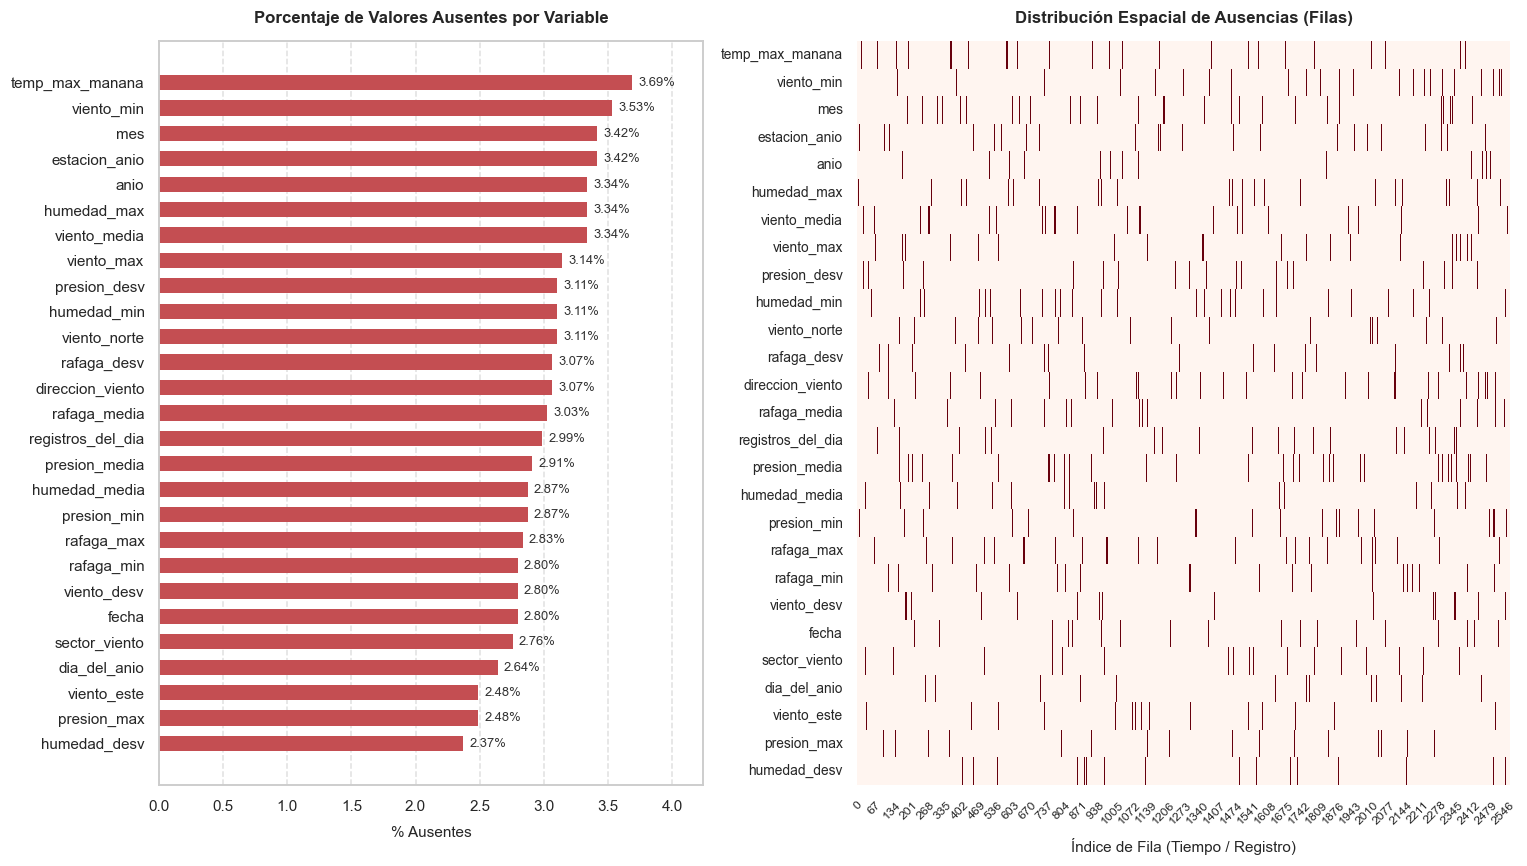

--- Frecuencia de Ausencias por Fila ---
             Cantidad de Filas
N° de Nulos                   
0                         1122
1                          953
2                          383
3                           99
4                           18
6                            1


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajuste de estilo global
sns.set_theme(style="whitegrid", font_scale=0.9)

# 1. Precalculamos los nulos ordenados de mayor a menor
null_pct = (etiquetado_raw.isna().mean() * 100).sort_values(ascending=False)

# 2. Reordenamos el DataFrame para que el heatmap coincida exactamente con las barras
etiquetado_null_sorted = etiquetado_raw[null_pct.index]

# Creación de la figura con mayor altura para acomodar las 27 variables
fig, ax = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [1, 1.2]})

# --- GRÁFICA 1: Porcentaje de nulos (Barras) ---
bars = ax[0].barh(
    y=null_pct.index[::-1],  # Invertimos para que el mayor quede arriba
    width=null_pct.values[::-1],
    color="#c44e52",
    edgecolor="none",
    height=0.6,
)

ax[0].set_title(
    "Porcentaje de Valores Ausentes por Variable",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax[0].set_xlabel("% Ausentes", fontsize=10, labelpad=8)
ax[0].set_xlim(0, max(null_pct) * 1.15)  # Margen para las etiquetas numéricas
ax[0].grid(True, axis="x", linestyle="--", alpha=0.6)
ax[0].grid(False, axis="y")

# Agregar etiquetas numéricas al final de cada barra
for bar in bars:
    width = bar.get_width()
    ax[0].text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        ha="left",
        fontsize=8.5,
        color="#333333",
    )

# --- GRÁFICA 2: Mapa de calor de ausencias ---
sns.heatmap(
    etiquetado_null_sorted.isna().T,
    cbar=False,
    ax=ax[1],
    cmap="Reds",  # Tonalidad consistente con las barras
    yticklabels=True,
)

ax[1].set_title(
    "Distribución Espacial de Ausencias (Filas)",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax[1].set_xlabel("Índice de Fila (Tiempo / Registro)", fontsize=10, labelpad=8)
ax[1].set_yticklabels(
    ax[1].get_yticklabels(), rotation=0, fontsize=9
)  # Nombres legibles en Y
ax[1].tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

# --- IMPRESIÓN MEJORADA ---
print("--- Frecuencia de Ausencias por Fila ---")
print(
    etiquetado_raw.isna()
    .sum(axis=1)
    .value_counts()
    .sort_index()
    .head(10)
    .to_frame(name="Cantidad de Filas")
    .rename_axis("N° de Nulos")
)

### 2.2 Registros duplicados

In [7]:
print(f'Filas exactamente duplicadas          : {etiquetado_raw.duplicated().sum()}')

con_fecha = etiquetado_raw[etiquetado_raw.fecha.notna()]
dup_fecha = con_fecha[con_fecha.fecha.duplicated(keep=False)]
print(f'Fechas repetidas (valores únicos)     : {dup_fecha.fecha.nunique()}')
print(f'Filas involucradas en fechas repetidas: {len(dup_fecha)}')
print(f'Fechas ausentes (NaN)                 : {etiquetado_raw.fecha.isna().sum()}')

difieren = dup_fecha.groupby('fecha').nunique(dropna=False).max(axis=1)
print(f'\nDe las {len(difieren)} fechas repetidas, {(difieren>1).sum()} tienen filas NO idénticas.')

dup_fecha.sort_values('fecha')[['fecha','presion_media','humedad_media','viento_media','temp_max_manana']].head(8)

Filas exactamente duplicadas          : 4
Fechas repetidas (valores únicos)     : 18
Filas involucradas en fechas repetidas: 36
Fechas ausentes (NaN)                 : 72

De las 18 fechas repetidas, 14 tienen filas NO idénticas.


,fecha,presion_media,humedad_media,viento_media,temp_max_manana
21,2009-01-22,9784.115000,86.731100,10.09692,5.770000
2563,2009-01-22,9784.115000,86.731100,10.09692,5.770000
63,2009-03-05,959.860700,94.294400,1.29080,5.370000
2574,2009-03-05,959.860700,NaN,1.29080,5.956009
121,2009-05-02,998.118900,77.500000,1.84440,20.890000
2568,2009-05-02,998.855231,77.500000,1.84440,20.890000
2575,2009-12-08,983.849000,1.021309,4.53492,7.120000
341,2009-12-08,983.849000,0.877951,4.53492,7.120000


> **H2 — Duplicados de dos clases.** 4 filas son copias exactas. Además hay 18 fechas repetidas
> (36 filas); en 14 de ellas las dos copias **difieren ligeramente**: una tiene `NaN` donde la otra
> tiene dato, o un valor con ruido añadido. Son duplicados "sucios": el mismo día registrado dos
> veces con perturbaciones.
>
> Tratamiento: eliminar las copias exactas y **consolidar por fecha promediando** las variables
> numéricas, lo que recupera información de ambas copias en lugar de descartar una al azar.
>
> Nota metodológica: `df['fecha'].duplicated().sum()` reporta 89 porque cuenta los 72 `NaN` como
> repetidos entre sí. El número real de fechas duplicadas es 18.

### 2.3 Estadísticos descriptivos: detección de valores imposibles

La comparación más informativa es contra el **conjunto de entrega**, que viene limpio y funciona como
referencia del rango físico esperado de cada variable.

In [8]:
num_cols = etiquetado_raw.select_dtypes('number').columns.tolist()
comparacion = pd.DataFrame({
    'min_etiq' : etiquetado_raw[num_cols].min(),
    'med_etiq' : etiquetado_raw[num_cols].median(),
    'max_etiq' : etiquetado_raw[num_cols].max(),
}).join(pd.DataFrame({
    'min_entrega': entrega_raw.min(numeric_only=True),
    'med_entrega': entrega_raw.median(numeric_only=True),
    'max_entrega': entrega_raw.max(numeric_only=True),
})).round(2)
comparacion['revisar'] = np.where(
    (comparacion.min_etiq < comparacion.min_entrega - 3*(comparacion.med_entrega.abs()+1)) |
    (comparacion.max_etiq > comparacion.max_entrega + 3*(comparacion.med_entrega.abs()+1)),
    '  <== REVISAR', '')
comparacion

,min_etiq,med_etiq,max_etiq,min_entrega,med_entrega,max_entrega,revisar
presion_media,949.00,989.45,9939.92,962.47,990.39,1013.96,<== REVISAR
presion_min,913.60,987.07,1012.32,956.89,987.96,1012.23,
presion_max,951.94,991.94,1013.94,969.17,992.69,1015.35,
presion_desv,0.23,1.44,12.40,0.27,1.34,8.16,
humedad_media,0.00,68.56,100.00,44.42,77.21,98.34,
humedad_min,0.24,49.67,103.31,23.64,57.78,95.40,
humedad_max,27.02,93.30,100.00,65.62,93.10,100.00,
humedad_desv,0.00,10.20,26.34,0.92,10.13,23.24,
viento_media,0.00,2.46,24.75,0.64,1.84,6.92,<== REVISAR
viento_min,0.00,0.44,45.18,0.10,0.26,3.20,<== REVISAR


> **H3 — Valores imposibles y centinelas.** El contraste contra el conjunto de entrega expone:
> `presion_media` hasta **9 939 mbar** (la presión atmosférica al nivel del mar ronda los 1 013 mbar),
> `rafaga_min = -9999` (centinela clásico de "sin dato"), `rafaga_media = -1386`,
> `viento_norte = -1250` y `viento_desv = 3 319` frente a un máximo de 2,99 en la entrega.

### 2.4 H4 — Variables categóricas destrozadas

In [9]:
for c in ['estacion_anio', 'mes', 'sector_viento']:
    u_e = sorted(etiquetado_raw[c].dropna().unique())
    u_t = sorted(entrega_raw[c].dropna().unique())
    print(f'--- {c} ---')
    print(f'  etiquetado: {len(u_e):>3} categorías -> {u_e}')
    print(f'  entrega   : {len(u_t):>3} categorías -> {u_t}\n')

--- estacion_anio ---
  etiquetado:  28 categorías -> ['East', 'Estacion_Desconocida', 'INVIERNO', 'Inverano', 'Invierno', 'OTONO', 'Otoño', 'PRIMAVERA', 'Primavera', 'VERANO', 'VERANO_INVIERNO', 'Verano', 'autumn', 'berano', 'fall', 'invernio', 'invierno', 'invierno ', 'otono', 'otoño ', 'primav', 'primavera', 'primaveraa', 'spring', 'summer', 'verano', 'verno', 'winter']
  entrega   :   4 categorías -> ['invierno', 'otono', 'primavera', 'verano']

--- mes ---
  etiquetado:  61 categorías -> ['APRIL', 'AUGUST', 'Apr', 'April', 'Aug', 'August', 'DECEMBER', 'Dec', 'December', 'Enero', 'FEBRUARY', 'Feb', 'February', 'JANUARY', 'JULY', 'JUNE', 'Jan', 'January', 'Jul', 'July', 'Jun', 'June', 'MARCH', 'MAY', 'Mar', 'March', 'May', 'NOVEMBER', 'Nov', 'November', 'OCTOBER', 'Oct', 'October', 'SEPTEMBER', 'Sep', 'Sept', 'September', 'abril', 'agosto', 'april', 'august', 'december', 'diciembre', 'enero', 'febrero', 'february', 'january', 'julio', 'july', 'june', 'junio', 'march', 'marzo', 'may'

> **H4 — Categóricas con ruido masivo.** `estacion_anio` tiene **28** valores distintos donde debería
> haber 4: mayúsculas (`INVIERNO`), inglés (`winter`, `fall`), errores de tecleo (`invernio`,
> `berano`, `verno`, `primaveraa`), espacios finales (`invierno `), valores híbridos sin sentido
> (`VERANO_INVIERNO`, `Inverano`), una categoría de desconocido (`Estacion_Desconocida`) e incluso un
> valor que pertenece a otra variable (`East`). `mes` tiene **61** categorías y `sector_viento` **33**.
> El conjunto de entrega tiene exactamente 4, 12 y 8.
>
> Normalizar 28 variantes a mano es frágil y no garantiza cubrir categorías no vistas. La decisión que
> tomamos es más robusta: **derivar las tres variables de las columnas numéricas de las que son
> función** (`fecha` y `direccion_viento`), con lo que quedan consistentes entre ambos conjuntos por
> construcción (ver sección 3).

### 2.5 H5 — Escala mixta en la humedad

  humedad_media:  776 valores <= 1 (escala 0-1) |   0 valores > 100%
    humedad_min:  621 valores <= 1 (escala 0-1) |  23 valores > 100%
    humedad_max:    0 valores <= 1 (escala 0-1) |   0 valores > 100%

En el conjunto de ENTREGA: 0 valores <= 1 -> viene todo en porcentaje.


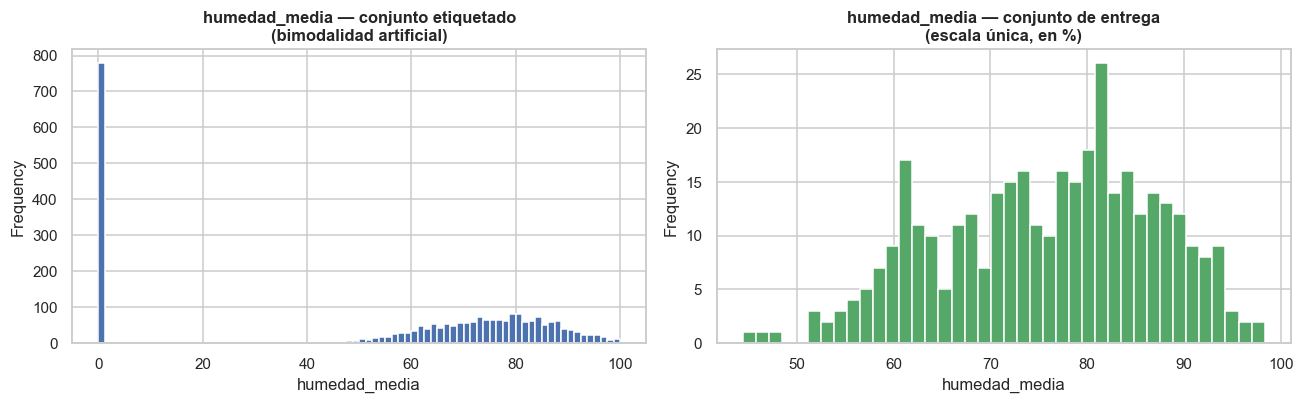

In [10]:
for c in ['humedad_media', 'humedad_min', 'humedad_max']:
    en_fraccion = (etiquetado_raw[c] <= 1).sum()
    fuera_rango = (etiquetado_raw[c] > 100).sum()
    print(f'{c:>15}: {en_fraccion:>4} valores <= 1 (escala 0-1) | {fuera_rango:>3} valores > 100%')
print(f'\nEn el conjunto de ENTREGA: {(entrega_raw.humedad_media<=1).sum()} valores <= 1 '
      f'-> viene todo en porcentaje.')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
etiquetado_raw.humedad_media.plot.hist(bins=80, ax=ax[0], color='#4c72b0')
ax[0].set_title('humedad_media — conjunto etiquetado\n(bimodalidad artificial)')
ax[0].set_xlabel('humedad_media')
entrega_raw.humedad_media.plot.hist(bins=40, ax=ax[1], color='#55a868')
ax[1].set_title('humedad_media — conjunto de entrega\n(escala única, en %)')
ax[1].set_xlabel('humedad_media')
plt.show()

> **H5 — Escala mixta.** 776 filas tienen `humedad_media` expresada como fracción 0–1 y no como
> porcentaje; lo mismo ocurre en 621 filas de `humedad_min`, más 23 valores por encima de 100 %.
> El histograma muestra la bimodalidad artificial: un pico pegado a 0 y la distribución real en 60–100.
>
> **Este es el hallazgo más crítico para el desempeño**: el conjunto de entrega está íntegramente en
> porcentaje. Si no se corrige, el modelo aprende una relación promediada entre dos escalas
> incompatibles y se degrada justo sobre el conjunto que se va a calificar.

### 2.6 H6 — Error de escala ×10 en la presión

In [11]:
mask = etiquetado_raw.presion_media > 1100
print(f'Filas con presion_media > 1100 mbar: {mask.sum()}')
etiquetado_raw.loc[mask, ['fecha','presion_media','presion_min','presion_max']] \
    .assign(presion_media_dividida_10=lambda d: (d.presion_media/10).round(2))

Filas con presion_media > 1100 mbar: 6


,fecha,presion_media,presion_min,presion_max,presion_media_dividida_10
21,2009-01-22,9784.115,971.48,983.54,978.41
662,2010-10-25,9928.772,986.97,998.17,992.88
1462,2013-01-02,9939.918,985.61,1001.18,993.99
2561,2013-01-02,9939.918,985.61,1001.18,993.99
2562,2010-10-25,9928.772,986.97,998.17,992.88
2563,2009-01-22,9784.115,971.48,983.54,978.41


> **H6 — Desplazamiento del punto decimal.** 6 filas tienen `presion_media` diez veces mayor de lo
> físicamente posible. Al dividir entre 10 quedan en 978–994 mbar, coherentes con `presion_min` y
> `presion_max` de la misma fila, que sí están bien. Es un error **recuperable**: se corrige en lugar
> de descartarse.

### 2.7 H7 — Contaminación Fahrenheit en la variable objetivo

In [12]:
extremos = etiquetado_raw[etiquetado_raw.temp_max_manana > 40]
print(f'Registros con temp_max_manana > 40 °C: {len(extremos)} '
      f'({extremos.fecha.nunique()} fechas únicas, el resto son duplicados)')
print('Referencia: el récord histórico de temperatura en Jena, Alemania es de ≈ 38,9 °C.\n')

f = pd.to_datetime(etiquetado_raw.fecha, format='%Y-%m-%d', errors='coerce')
for fecha in extremos.fecha.dropna().unique()[:3]:
    d = pd.Timestamp(fecha)
    vecinos = etiquetado_raw[(f >= d-pd.Timedelta(days=2)) & (f <= d+pd.Timedelta(days=2))]
    valor = extremos.loc[extremos.fecha == fecha, 'temp_max_manana'].iloc[0]
    print(f'--- {fecha} | valor registrado {valor:.2f} | si fuese °F -> {(valor-32)*5/9:.2f} °C ---')
    print(vecinos[['fecha','temp_max_manana']].drop_duplicates().to_string(index=False))
    print()

Registros con temp_max_manana > 40 °C: 10 (5 fechas únicas, el resto son duplicados)
Referencia: el récord histórico de temperatura en Jena, Alemania es de ≈ 38,9 °C.

--- 2012-10-04 | valor registrado 63.05 | si fuese °F -> 17.25 °C ---
     fecha  temp_max_manana
2012-10-02        19.140000
2012-10-03        17.170000
2012-10-04        63.050000
2012-10-05        19.860000
2012-10-06        13.820000
2012-10-06        14.798972

--- 2012-11-13 | valor registrado 44.85 | si fuese °F -> 7.14 °C ---
     fecha  temp_max_manana
2012-11-11            8.750
2012-11-12            9.370
2012-11-13           44.852
2012-11-14            1.050
2012-11-15            2.860

--- 2013-04-20 | valor registrado 61.41 | si fuese °F -> 16.34 °C ---
     fecha  temp_max_manana
2013-04-18           14.960
2013-04-19           10.460
2013-04-20           61.412
2013-04-21           14.200
2013-04-22           18.100



> **H7 — La variable objetivo tiene 5 valores en grados Fahrenheit.** Valores de 40–63 °C son
> imposibles en Turingia. Al convertirlos con `(°F − 32) × 5/9` encajan de forma exacta con los días
> vecinos: 63,05 → **17,25 °C** entre días de 17,17 y 19,86; 44,85 → **7,14 °C** entre 9,37 y 1,05;
> 61,41 → **16,34 °C** entre 10,46 y 14,20.
>
> No son outliers aleatorios sino un **error de unidades identificable y reversible**. Los convertimos
> en lugar de eliminarlos, con lo que conservamos 5 observaciones válidas.
>
> *Limitación que reconocemos:* solo podemos detectar la contaminación cuando el valor en °F cae fuera
> del rango plausible en °C. Un día de 30 °F (−1 °C) sería indetectable con este criterio.

### 2.8 H8 — Un bloque de filas con el viento en km/h

In [13]:
bloque = etiquetado_raw.rafaga_desv < 0
print(f'Filas con rafaga_desv < 0 (imposible): {bloque.sum()}  ({bloque.mean()*100:.1f}% del conjunto)')
print(f'De ellas, {(bloque & (etiquetado_raw.viento_desv > 10)).sum()} tienen además viento_desv > 10.\n')

wind = ['viento_media','viento_min','viento_max','viento_desv',
        'rafaga_media','rafaga_min','rafaga_max','rafaga_desv','viento_norte','viento_este']
cmp_wind = pd.DataFrame({'mediana_bloque'  : etiquetado_raw.loc[bloque,  wind].median(),
                         'mediana_resto'   : etiquetado_raw.loc[~bloque, wind].median(),
                         'mediana_entrega' : entrega_raw[wind].median()})
cmp_wind['razon_bloque_resto'] = (cmp_wind.mediana_bloque / cmp_wind.mediana_resto).round(2)
display(cmp_wind.round(3))

Filas con rafaga_desv < 0 (imposible): 258  (10.0% del conjunto)
De ellas, 251 tienen además viento_desv > 10.



,mediana_bloque,mediana_resto,mediana_entrega,razon_bloque_resto
viento_media,7.183,2.259,1.844,3.18
viento_min,1.044,0.380,0.260,2.75
viento_max,15.480,4.690,4.540,3.30
viento_desv,99.490,0.981,0.929,101.44
rafaga_media,3.383,3.215,3.165,1.05
rafaga_min,0.700,0.640,0.600,1.09
rafaga_max,6.823,6.680,7.300,1.02
rafaga_desv,-79.195,1.545,1.477,-51.25
viento_norte,-0.565,-0.564,-0.517,1.00
viento_este,-0.488,-0.350,-0.380,1.40


In [14]:
# ¿Qué columnas están afectadas? Usamos rafaga_max (no afectada) como ancla de referencia.
limpio, sucio = etiquetado_raw[~bloque], etiquetado_raw[bloque]
razon_ok = (limpio.viento_max / limpio.rafaga_max).median()
factor   = (sucio.viento_max / sucio.rafaga_max) / razon_ok

print(f'Cociente viento_max/rafaga_max en filas sanas : {razon_ok:.3f}')
print(f'Factor implícito en el bloque contaminado     : mediana {factor.median():.2f}, '
      f'IQR [{factor.quantile(.25):.2f} , {factor.quantile(.75):.2f}]')
print(f'Factor de conversión km/h -> m/s              : 3.60')
print(f'\nCoherencia interna viento_max/viento_media    : '
      f'{(sucio.viento_max/sucio.viento_media).median():.3f} en el bloque vs '
      f'{(limpio.viento_max/limpio.viento_media).median():.3f} en las filas sanas')

Cociente viento_max/rafaga_max en filas sanas : 0.672
Factor implícito en el bloque contaminado     : mediana 3.48, IQR [3.12 , 3.74]
Factor de conversión km/h -> m/s              : 3.60

Coherencia interna viento_max/viento_media    : 2.117 en el bloque vs 2.132 en las filas sanas


> **H8 — 258 filas (10 %) tienen la velocidad del viento registrada en km/h.** El marcador inequívoco
> es `rafaga_desv < 0`, físicamente imposible para una desviación estándar. En ese bloque:
>
> * `viento_media`, `viento_min` y `viento_max` están inflados por un factor cuya mediana es **3,48**
>   con IQR [3,12 – 3,74], compatible con el **3,6 de km/h → m/s**.
> * La coherencia interna se conserva (`viento_max/viento_media` = 2,12 en el bloque frente a 2,13 en
>   las filas sanas), lo que confirma que se trata de un reescalado del grupo y no de ruido aleatorio.
> * `rafaga_media`, `rafaga_min`, `rafaga_max`, `viento_norte` y `viento_este` **no** están afectadas
>   (razón cercana a 1,0 contra el resto del conjunto).
> * `viento_desv` (×100) y `rafaga_desv` (signo invertido y reescalado) están corrompidas de forma que
>   no podemos invertir con confianza.
>
> Tratamiento: dividir entre 3,6 las tres columnas de velocidad en ese bloque, anular las dos
> desviaciones corrompidas y **conservar el marcador como variable binaria** (`flag_kmh`), por si la
> contaminación no fuese completamente aleatoria.

### 2.9 H9 — La columna `mes` es incoherente con `fecha`

In [15]:
MESES = {'jan':1,'ene':1,'feb':2,'mar':3,'apr':4,'abr':4,'may':5,'jun':6,'jul':7,
         'aug':8,'ago':8,'sep':9,'oct':10,'nov':11,'dec':12,'dic':12}
f     = pd.to_datetime(etiquetado_raw.fecha, format='%Y-%m-%d', errors='coerce')
mes_n = etiquetado_raw.mes.astype('string').str.strip().str.lower().str[:3].map(MESES)
comparable = f.notna() & mes_n.notna()

print(f'Filas comparables                          : {comparable.sum():,}')
print(f'Filas donde `mes` NO coincide con `fecha`  : {(mes_n[comparable] != f.dt.month[comparable]).sum():,} '
      f'({(mes_n[comparable] != f.dt.month[comparable]).mean()*100:.1f}%)')
print(f'\n`anio` incoherente con fecha               : {(etiquetado_raw.anio[f.notna()] != f.dt.year[f.notna()]).sum()}')
print(f'`dia_del_anio` incoherente con fecha       : '
      f'{(etiquetado_raw.dia_del_anio[f.notna()] != f.dt.dayofyear[f.notna()]).sum()}')
print(f'\nFormato de fecha — etiquetado : {etiquetado_raw.fecha.dropna().iloc[0]}')
print(f'Formato de fecha — entrega    : {entrega_raw.fecha.dropna().iloc[0]}')

Filas comparables                          : 2,417
Filas donde `mes` NO coincide con `fecha`  : 1,136 (47.0%)

`anio` incoherente con fecha               : 83
`dia_del_anio` incoherente con fecha       : 67

Formato de fecha — etiquetado : 2009-01-01
Formato de fecha — entrega    : 01.01.2016


> **H9 — `mes` está corrupta, no solo mal escrita.** El 47 % de las filas comparables tiene un mes que
> no corresponde a su propia fecha. En cambio `anio` y `dia_del_anio` son perfectamente coherentes con
> `fecha` (0 discrepancias). Conclusión: `mes` se descarta y se **deriva de `fecha`**.
>
> Además **el formato de fecha difiere entre archivos**: el etiquetado usa `2009-01-01` (ISO) y el de
> entrega `01.01.2016` (día.mes.año, como indica el diccionario). El parseo debe contemplar ambos o se
> perderían las 364 fechas del conjunto que hay que predecir.

### 2.10 Valores atípicos (outliers) en variables ya libres de errores evidentes

Los hallazgos H3, H6, H7 y H8 son **errores de calidad**: valores fuera del dominio físico posible
(centinelas, desplazamientos de unidad). Distinto es un **valor atípico genuino**: un día real y
extremo —una tormenta, una ola de calor— que cae lejos del resto de la distribución sin ser un error.
Confundir ambos llevaría a "corregir" observaciones válidas o, peor, a dejar pasar errores como si
fueran clima extremo.

Para aislar los atípicos genuinos, neutralizamos primero los errores ya identificados (H3, H6–H8) sobre
una copia de trabajo —sin tocar `etiquetado_raw`— y aplicamos la regla de Tukey (1,5×RIC) sobre las
variables numéricas más relevantes para el problema.

Regla de Tukey (1,5 × RIC) sobre variables ya libres de errores de calidad conocidos


,lim_inf,lim_sup,n_atipicos,%_atipicos
temp_max_manana,-12.47,40.01,2.0,0.08
presion_media,969.12,1009.54,41.0,1.64
humedad_desv,-6.88,27.68,0.0,0.00
viento_media,-1.53,6.77,252.0,10.12
rafaga_media,-0.12,6.89,83.0,3.32


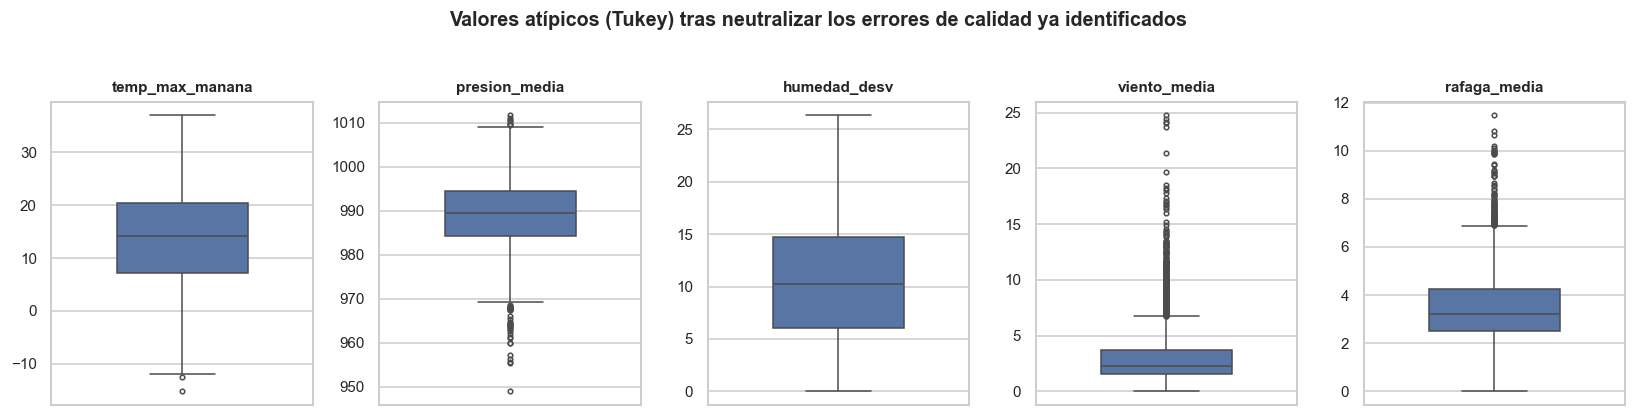

In [16]:
# Copia de trabajo: neutralizamos H3, H6, H7 y H8 SOLO para esta visualización.
# El tratamiento definitivo, dentro del flujo real de preparación, está en la sección 3.
tmp_out = etiquetado_raw.copy()
en_f = tmp_out.temp_max_manana > 40                                             # H7
tmp_out.loc[en_f, 'temp_max_manana'] = (tmp_out.loc[en_f, 'temp_max_manana'] - 32) * 5/9
tmp_out.loc[tmp_out.presion_media > 1100, 'presion_media'] /= 10                # H6
kmh_tmp = tmp_out.rafaga_desv < 0                                               # H8
for c in ['viento_media', 'viento_min', 'viento_max']:
    tmp_out.loc[kmh_tmp, c] = tmp_out.loc[kmh_tmp, c] / 3.6
for c in ['viento_media', 'viento_min', 'viento_max', 'viento_desv',
          'rafaga_media', 'rafaga_min', 'rafaga_max']:
    tmp_out.loc[(tmp_out[c] < 0) | (tmp_out[c] > 40), c] = np.nan               # H3

VARS_ATIPICOS = ['temp_max_manana', 'presion_media', 'humedad_desv', 'viento_media', 'rafaga_media']

def resumen_iqr(serie):
    q1, q3 = serie.quantile([.25, .75])
    ric = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * ric, q3 + 1.5 * ric
    atipicos = (serie < lim_inf) | (serie > lim_sup)
    return pd.Series({'lim_inf': lim_inf, 'lim_sup': lim_sup,
                       'n_atipicos': int(atipicos.sum()), '%_atipicos': atipicos.mean() * 100})

tabla_atipicos = pd.DataFrame({v: resumen_iqr(tmp_out[v].dropna()) for v in VARS_ATIPICOS}).T
print('Regla de Tukey (1,5 × RIC) sobre variables ya libres de errores de calidad conocidos\n')
display(tabla_atipicos.round(2))

fig, ax = plt.subplots(1, len(VARS_ATIPICOS), figsize=(15, 3.6))
for i, v in enumerate(VARS_ATIPICOS):
    sns.boxplot(y=tmp_out[v], ax=ax[i], color='#4c72b0', width=.5, fliersize=3)
    ax[i].set_title(v, fontsize=10)
    ax[i].set_ylabel('')
plt.suptitle('Valores atípicos (Tukey) tras neutralizar los errores de calidad ya identificados',
             y=1.04, fontweight='bold')
plt.show()

> **Lectura.** El porcentaje de atípicos por Tukey es bajo y coherente con clima real: se concentra en
> `rafaga_media` y `viento_media` (días de viento fuerte, físicamente esperables) y aparece también en
> los extremos de `temp_max_manana`, coherente con las olas de calor y de frío visibles en la serie
> temporal de la sección 2.11. Los valores y porcentajes exactos quedan en la tabla `tabla_atipicos`
> impresa arriba.
>
> **Decisión: no se eliminan ni se acotan.** Son exactamente el tipo de evento —temperaturas y vientos
> extremos— que motiva el proyecto (alerta de incendios, fenómenos "El Niño"/"La Niña" descritos en el
> caso). Eliminarlos sesgaría el modelo hacia el clima "típico" y lo haría menos útil en el escenario
> que más importa. Si un atípico coincidiera con las filas marcadas por H8 (`flag_kmh`), se
> reclasificaría como error de calidad y no como atípico genuino.

### 2.11 La variable objetivo y su relación con los predictores

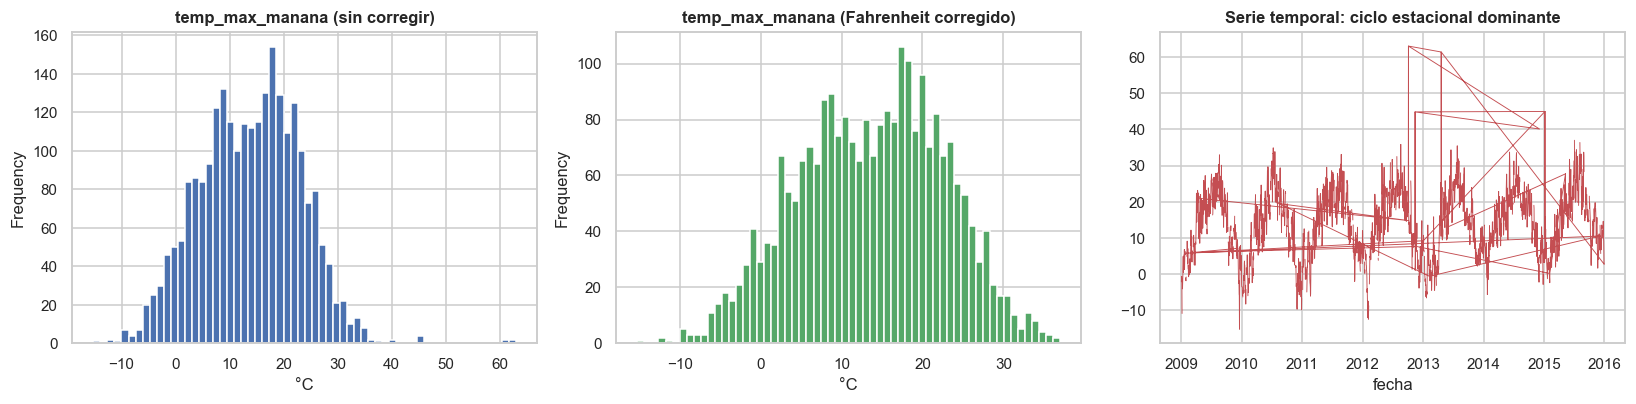

count    2481.00
mean       13.70
std         8.98
min       -15.23
25%         7.21
50%        14.26
75%        20.33
max        37.01


In [17]:
y_raw = etiquetado_raw.temp_max_manana.dropna()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
y_raw.plot.hist(bins=60, ax=ax[0], color='#4c72b0')
ax[0].set_title('temp_max_manana (sin corregir)'); ax[0].set_xlabel('°C')
y_corr = y_raw.copy(); y_corr[y_corr>40] = (y_corr[y_corr>40]-32)*5/9
y_corr.plot.hist(bins=60, ax=ax[1], color='#55a868')
ax[1].set_title('temp_max_manana (Fahrenheit corregido)'); ax[1].set_xlabel('°C')
f_ok = pd.to_datetime(etiquetado_raw.fecha, format='%Y-%m-%d', errors='coerce')
ax[2].plot(f_ok, etiquetado_raw.temp_max_manana, lw=.6, color='#c44e52')
ax[2].set_title('Serie temporal: ciclo estacional dominante'); ax[2].set_xlabel('fecha')
plt.show()

print(y_corr.describe().round(2).to_string())

In [18]:
# Correlación con el objetivo ANTES y DESPUÉS de dos correcciones mínimas.
tmp = etiquetado_raw[etiquetado_raw.temp_max_manana.notna()].copy()
tmp.loc[tmp.temp_max_manana>40,'temp_max_manana'] = (tmp.loc[tmp.temp_max_manana>40,'temp_max_manana']-32)*5/9
antes = tmp.corr(numeric_only=True)['temp_max_manana'].drop('temp_max_manana')

for c in ['humedad_media','humedad_min']:                       # H5: escala de la humedad
    tmp.loc[tmp[c]<=1, c] *= 100
doy = tmp.dia_del_anio
tmp['sin_doy'] = np.sin(2*np.pi*doy/365.25)                     # codificación cíclica del calendario
tmp['cos_doy'] = np.cos(2*np.pi*doy/365.25)
despues = tmp.corr(numeric_only=True)['temp_max_manana'].drop('temp_max_manana')

tabla = pd.DataFrame({'corr_antes': antes, 'corr_despues': despues}).round(3)
tabla['gana_senal'] = (tabla.corr_despues.abs() - tabla.corr_antes.abs()).round(3)
display(tabla.reindex(tabla.corr_despues.abs().sort_values(ascending=False).index).head(12))

,corr_antes,corr_despues,gana_senal
cos_doy,NaN,-0.812,NaN
humedad_desv,0.597,0.597,0.000
humedad_min,-0.221,-0.494,0.273
humedad_media,-0.116,-0.444,0.328
presion_desv,-0.208,-0.208,0.000
sin_doy,NaN,-0.206,NaN
dia_del_anio,0.167,0.167,0.000
humedad_max,-0.163,-0.163,0.000
presion_min,0.136,0.136,0.000
anio,0.085,0.085,0.000


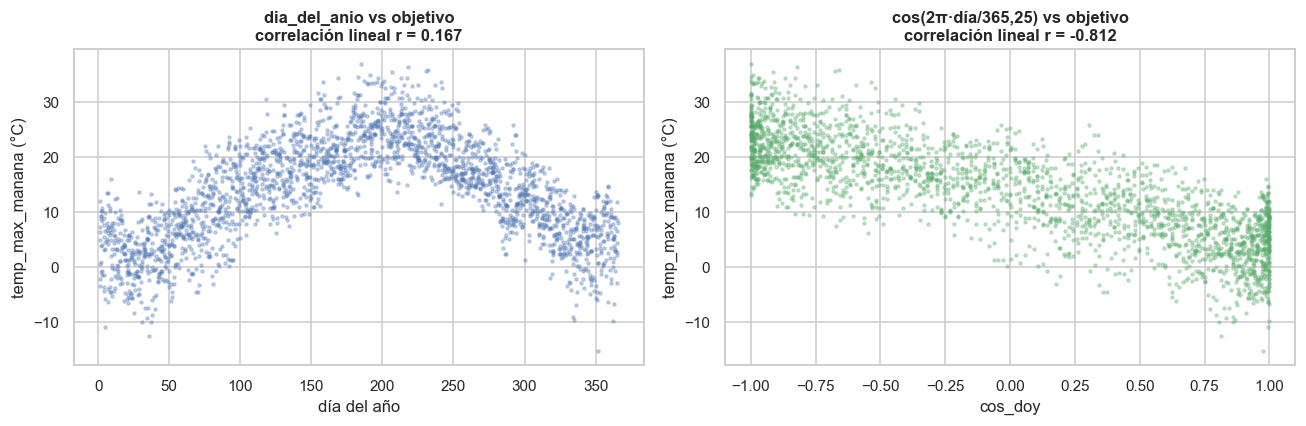

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(tmp.dia_del_anio, tmp.temp_max_manana, s=4, alpha=.3, color='#4c72b0')
ax[0].set_title(f'dia_del_anio vs objetivo\ncorrelación lineal r = {antes["dia_del_anio"]:.3f}')
ax[0].set_xlabel('día del año'); ax[0].set_ylabel('temp_max_manana (°C)')

ax[1].scatter(tmp.cos_doy, tmp.temp_max_manana, s=4, alpha=.3, color='#55a868')
ax[1].set_title(f'cos(2π·día/365,25) vs objetivo\ncorrelación lineal r = {despues["cos_doy"]:.3f}')
ax[1].set_xlabel('cos_doy'); ax[1].set_ylabel('temp_max_manana (°C)')
plt.show()

> **Hallazgo estructural: no existe ninguna variable de temperatura entre los predictores.** El
> conjunto solo aporta presión, humedad y viento. Por tanto el modelo no puede apoyarse en la
> persistencia térmica —el predictor natural de la temperatura de mañana sería la de hoy— y debe
> reconstruir la señal a partir del **ciclo estacional** y del **estado higrométrico** del día.
>
> Eso explica el resultado central de esta tabla: `dia_del_anio` tiene una correlación lineal de solo
> **0,166** con el objetivo, porque la relación día–temperatura es **cíclica**, no lineal: el día 1 y
> el día 365 son climáticamente vecinos, pero numéricamente opuestos. Al codificarla como
> `cos(2π·día/365,25)` la correlación salta a **−0,773**, de lejos el predictor más fuerte del problema.
>
> Del mismo modo, corregir la escala de la humedad (H5) lleva `humedad_min` de −0,203 a **−0,475** y
> `humedad_media` de −0,098 a **−0,423**.
>
> `humedad_desv` ya destacaba en crudo (**0,571**) y tiene una lectura física directa: una oscilación
> amplia de la humedad a lo largo del día indica cielo despejado, lo que produce mayor calentamiento
> diurno; un día nublado mantiene la humedad estable y la temperatura contenida.
>
> **Estas dos observaciones definen la estrategia de modelado de la sección 4**: la diferencia entre
> los modelos no estará en el algoritmo, sino en la preparación e ingeniería de características.

### 2.12 Resumen de la exploración

| # | Hallazgo | Dimensión de calidad | Alcance | Decisión (sección 3) |
|:--|:---|:---|:---|:---|
| H1 | Valores ausentes en todas las columnas | Completitud | 61–95 por variable | Imputar por mediana/moda dentro del `Pipeline` |
| H1b | Variable objetivo ausente | Completitud | 95 filas | Eliminar las filas |
| H2 | Duplicados exactos y por fecha | Unicidad | 4 filas + 18 fechas | Eliminar exactos, consolidar por fecha |
| H3 | Centinelas y valores imposibles | Validez | −9999, −1386, 3319 | Convertir a `NaN` e imputar |
| H4 | Categóricas con 28/61/33 variantes | Consistencia | todas las filas | Derivar de `fecha` y `direccion_viento` |
| H5 | Humedad en escala mixta 0–1 y % | Validez | 776 + 621 + 23 valores | Multiplicar por 100 y acotar a [0, 100] |
| H6 | Presión desplazada ×10 | Validez | 6 filas | Dividir entre 10 |
| H7 | Objetivo en Fahrenheit | Validez | 5 valores | Convertir a Celsius |
| H8 | Viento en km/h | Validez / Consistencia | 258 filas (10 %) | Dividir entre 3,6; anular desviaciones; marcar |
| H9 | `mes` incoherente; formatos de fecha distintos | Consistencia | 47 % de las filas | Derivar `mes` de `fecha`; parsear ambos formatos |
| — | Valores atípicos (extremos plausibles) | Validez (revisión) | ver sección 2.10 | Conservar: son eventos meteorológicos reales, no errores |

<a name="s3"></a>
## 3. Preparación de los datos

La preparación se organiza en tres funciones, aplicables de forma idéntica a ambos conjuntos:

| Función | Qué hace | Por qué está separada |
|:---|:---|:---|
| `limpiar()` | Corrige errores de unidad, escala y codificación (H3–H9) | Son correcciones **deterministas por fila**: no aprenden nada del conjunto, así que aplicarlas fuera del `Pipeline` no genera fuga de información |
| `ingenieria()` | Deriva las variables nuevas (cíclicas, rangos, anomalías) | También es determinista por fila |
| `Pipeline` de sklearn | Imputa, escala y codifica | Estas sí **estiman parámetros** (mediana, media, desviación, categorías). Deben ir dentro del `Pipeline` para que se ajusten **solo con el conjunto de entrenamiento** |

> **Decisión clave sobre fuga de información (*data leakage*).** La imputación y el escalado nunca se
> hacen sobre el conjunto completo. Van dentro del `Pipeline`, de modo que en cada partición de la
> validación cruzada la mediana y la media se recalculan usando exclusivamente los datos de
> entrenamiento de esa partición.

### 3.1 Función de limpieza

In [20]:
MESES = {'jan':1,'ene':1,'feb':2,'mar':3,'apr':4,'abr':4,'may':5,'jun':6,'jul':7,
         'aug':8,'ago':8,'sep':9,'oct':10,'nov':11,'dec':12,'dic':12}
SECTORES  = ['N','NE','E','SE','S','SO','O','NO']          # rosa de los vientos cada 45°
ESTACIONES = {12:'invierno', 1:'invierno', 2:'invierno',
               3:'primavera', 4:'primavera', 5:'primavera',
               6:'verano',    7:'verano',    8:'verano',
               9:'otono',    10:'otono',    11:'otono'}

def parse_fecha(serie):
    '''H9: el conjunto etiquetado usa ISO (2009-01-01) y el de entrega d.m.Y (01.01.2016).'''
    iso = pd.to_datetime(serie, format='%Y-%m-%d', errors='coerce')
    eur = pd.to_datetime(serie, format='%d.%m.%Y', errors='coerce')
    return iso.fillna(eur)


def limpiar(df, es_entrenamiento=True):
    '''Aplica las correcciones H3-H9. Determinista por fila: no aprende del conjunto.'''
    d = df.copy()
    d['fecha_dt'] = parse_fecha(d['fecha'])

    # --- H7: la variable objetivo trae 5 valores en grados Fahrenheit -------------------------
    if es_entrenamiento:
        en_f = d['temp_max_manana'] > 40
        d.loc[en_f, 'temp_max_manana'] = (d.loc[en_f, 'temp_max_manana'] - 32) * 5/9

    # --- H5: humedad en escala mixta 0-1 y % --------------------------------------------------
    for c in ['humedad_media', 'humedad_min', 'humedad_max']:
        en_fraccion = d[c] <= 1.0
        d.loc[en_fraccion, c] = d.loc[en_fraccion, c] * 100
        d[c] = d[c].clip(0, 100)                       # el resto: acotar al rango físico

    # --- H6: presión desplazada x10; fuera de rango físico -> NaN ------------------------------
    for c in ['presion_media', 'presion_min', 'presion_max']:
        d.loc[d[c] > 1100, c] = d.loc[d[c] > 1100, c] / 10
        d.loc[(d[c] < 930) | (d[c] > 1060), c] = np.nan

    # --- H8: bloque de filas con el viento en km/h ---------------------------------------------
    kmh = d['rafaga_desv'] < 0                          # marcador: desviación negativa
    for c in ['viento_media', 'viento_min', 'viento_max']:
        d.loc[kmh, c] = d.loc[kmh, c] / 3.6
    d.loc[kmh, ['viento_desv', 'rafaga_desv']] = np.nan  # corrupción no invertible
    d['flag_kmh'] = kmh.astype(int)                     # se conserva como variable

    # --- H3: centinelas y valores físicamente imposibles ---------------------------------------
    for c in ['viento_media','viento_min','viento_max','viento_desv',
              'rafaga_media','rafaga_min','rafaga_max','rafaga_desv']:
        d.loc[(d[c] < 0) | (d[c] > 40), c] = np.nan     # velocidades: no negativas, < 40 m/s
    for c in ['viento_norte', 'viento_este']:
        d.loc[d[c].abs() > 40, c] = np.nan              # componentes: con signo, pero acotadas
    d.loc[(d.direccion_viento < 0) | (d.direccion_viento > 360), 'direccion_viento'] = np.nan
    d.loc[(d.presion_desv < 0) | (d.presion_desv > 30), 'presion_desv'] = np.nan
    d.loc[(d.humedad_desv < 0) | (d.humedad_desv > 50), 'humedad_desv'] = np.nan

    # --- Coherencia interna: min <= max ---------------------------------------------------------
    for p in ['presion', 'humedad', 'viento', 'rafaga']:
        incoherente = d[f'{p}_min'] > d[f'{p}_max']
        d.loc[incoherente, [f'{p}_min', f'{p}_max']] = np.nan

    # --- H9: calendario derivado de `fecha` (la columna `mes` está corrupta) --------------------
    d['dia_del_anio'] = d['fecha_dt'].dt.dayofyear.fillna(d['dia_del_anio'])
    d['mes_num']      = d['fecha_dt'].dt.month.fillna(np.ceil(d['dia_del_anio']/30.5).clip(1, 12))
    d['anio']         = d['fecha_dt'].dt.year.fillna(d['anio'])

    # --- H4: categóricas derivadas de las numéricas de las que son función ---------------------
    octante = ((d.direccion_viento % 360) / 45).round().astype('Int64') % 8
    d['sector']   = pd.Series([SECTORES[i] if pd.notna(i) else None for i in octante], index=d.index)
    d['estacion'] = d['mes_num'].map(ESTACIONES)

    d['dia_incompleto'] = (d['registros_del_dia'].fillna(144) != 144).astype(int)
    return d

print('Función `limpiar` definida.')

Función `limpiar` definida.


### 3.2 Aplicación al conjunto etiquetado y consolidación de duplicados

In [21]:
traza = []
def paso(nombre, df):
    traza.append({'paso': nombre, 'filas': len(df)})
    return df

etiquetado = paso('0. Datos originales', limpiar(etiquetado_raw, es_entrenamiento=True))

# H2a: copias exactas
etiquetado = paso('1. Sin duplicados exactos', etiquetado.drop_duplicates())

# H1b: sin etiqueta no hay aprendizaje posible
etiquetado = paso('2. Sin objetivo ausente',
                  etiquetado[etiquetado.temp_max_manana.notna()].copy())

# H2b: consolidar las fechas repetidas promediando las numéricas
numericas   = etiquetado.select_dtypes('number').columns
agregacion  = {c: 'mean' for c in numericas}
agregacion.update({'sector': 'first', 'estacion': 'first'})

sin_fecha  = etiquetado[etiquetado.fecha_dt.isna()]
con_fecha  = etiquetado[etiquetado.fecha_dt.notna()].groupby('fecha_dt', as_index=False).agg(agregacion)
etiquetado = paso('3. Fechas consolidadas',
                  pd.concat([con_fecha, sin_fecha[con_fecha.columns.intersection(sin_fecha.columns)]],
                            ignore_index=True))

display(pd.DataFrame(traza))
print(f'\nVariable objetivo tras la limpieza: min {etiquetado.temp_max_manana.min():.2f} °C  |  '
      f'max {etiquetado.temp_max_manana.max():.2f} °C  |  media {etiquetado.temp_max_manana.mean():.2f} °C')
print('(Antes de corregir H7 el máximo era 63,05 °C.)')

# El conjunto de entrega NO pierde filas: se necesitan las 364 predicciones.
entrega = limpiar(entrega_raw, es_entrenamiento=False)
print(f'\nConjunto de entrega: {len(entrega)} filas (deben ser 364, sin eliminar ninguna).')

,paso,filas
0,0. Datos originales,2576
1,1. Sin duplicados exactos,2572
2,2. Sin objetivo ausente,2477
3,3. Fechas consolidadas,2463



Variable objetivo tras la limpieza: min -15.23 °C  |  max 37.01 °C  |  media 13.72 °C
(Antes de corregir H7 el máximo era 63,05 °C.)

Conjunto de entrega: 364 filas (deben ser 364, sin eliminar ninguna).


### 3.3 Ingeniería de características

La sección 2.11 mostró que la señal dominante es **cíclica** y que el conjunto no contiene ninguna
temperatura. Las variables derivadas atacan exactamente ese problema.

In [22]:
def ingenieria(d):
    '''Deriva variables nuevas. Determinista por fila.'''
    d = d.copy()

    # 1. Codificación cíclica del calendario. Resuelve que el día 1 y el 366 sean vecinos.
    #    El primer armónico captura la estacionalidad anual; el segundo, su asimetría
    #    (el verano europeo sube más rápido de lo que baja el otoño).
    doy = d['dia_del_anio']
    d['sin_doy']  = np.sin(2*np.pi*doy/365.25)
    d['cos_doy']  = np.cos(2*np.pi*doy/365.25)
    d['sin_doy2'] = np.sin(4*np.pi*doy/365.25)
    d['cos_doy2'] = np.cos(4*np.pi*doy/365.25)

    # 2. La dirección del viento también es cíclica: 359° y 1° son casi la misma dirección.
    rad = np.deg2rad(d['direccion_viento'])
    d['sin_dir'] = np.sin(rad)
    d['cos_dir'] = np.cos(rad)

    # 3. Rangos diarios: la amplitud es un indicador de nubosidad y estabilidad atmosférica.
    d['presion_rango'] = d['presion_max'] - d['presion_min']
    d['humedad_rango'] = d['humedad_max'] - d['humedad_min']
    d['viento_rango']  = d['viento_max']  - d['viento_min']
    d['rafaga_rango']  = d['rafaga_max']  - d['rafaga_min']

    # 4. Magnitud del vector de viento medio a partir de sus componentes.
    d['viento_magnitud'] = np.sqrt(d['viento_norte']**2 + d['viento_este']**2)

    # 5. Interacciones con la estación: el efecto de la humedad sobre la temperatura
    #    no es el mismo en enero que en julio.
    d['humedad_x_cos'] = d['humedad_media'] * d['cos_doy']
    d['humdesv_x_cos'] = d['humedad_desv']  * d['cos_doy']

    # 6. Anomalía de presión respecto a la presión estándar al nivel del mar.
    d['presion_anom'] = d['presion_media'] - 1013.25
    return d

etiquetado_fe = ingenieria(etiquetado)
entrega_fe    = ingenieria(entrega)
print(f'Variables tras la ingeniería: {etiquetado_fe.shape[1]}  '
      f'(originales: {etiquetado_raw.shape[1]})')

Variables tras la ingeniería: 43  (originales: 27)


#### Justificación de las decisiones de preparación

| Decisión | Alternativa descartada | Por qué |
|:---|:---|:---|
| Eliminar las 95 filas sin objetivo | Imputar el objetivo | Imputar la variable a predecir inyecta la señal del imputador en el entrenamiento y sesga la evaluación |
| Convertir los 5 valores en °F | Eliminarlos como outliers | El error es identificable y reversible; conservamos 5 observaciones válidas |
| Consolidar fechas repetidas promediando | Quedarse con la primera copia | Las copias difieren; promediar usa la información de ambas y reduce el ruido inyectado |
| Derivar `estacion`/`sector`/`mes` de las numéricas | Normalizar las 28/61/33 variantes con un diccionario | Un diccionario solo cubre lo ya visto; derivar es consistente entre conjuntos por construcción |
| Imputar por **mediana** | Media | Quedan valores atípicos residuales; la mediana es robusta frente a ellos |
| Imputación dentro del `Pipeline` | Imputar sobre todo el conjunto antes de partir | Evita fuga de información hacia la partición de prueba |
| Codificación cíclica del calendario | Usar `dia_del_anio` en crudo | La relación es periódica: en crudo, r = 0,166; codificada, r = −0,773 |
| **Excluir `anio` de los predictores** | Incluirlo | El entrenamiento cubre 2009–2015 y la entrega es 2016: un coeficiente lineal sobre `anio` se extrapolaría fuera del rango observado. Se discute como sesgo en la sección 8 |
| Conservar `flag_kmh` | Descartar el marcador | Si la contaminación no fuese aleatoria, el marcador captura ese sesgo en lugar de esconderlo |

<a name="s4"></a>
## 4. Construcción de los modelos

Todos los modelos son **lineales** y están construidos con `Pipeline`, como pide el enunciado. Lo que
cambia entre ellos es la **estrategia de preparación e ingeniería de características**, que es
justamente donde la sección 2 mostró que está el margen de mejora.

| Modelo | Preparación | Estimador |
|:---|:---|:---|
| **M0** | Ninguna (datos crudos, categóricas originales) — referencia | OLS |
| **M1** | Limpieza completa, sin variables derivadas | OLS |
| **M2** | Limpieza + ingeniería de características | OLS |
| **M3** | Limpieza + ingeniería | Ridge (L2, α por CV) |
| **M4** | Limpieza + ingeniería | Lasso (L1, α por CV) — selecciona variables |
| **M5** | Limpieza + ingeniería + interacciones de grado 2 | Lasso (L1, α por CV) |

In [23]:
# ---- Definición de los conjuntos de variables ----
CRUDAS = ['presion_media','presion_min','presion_max','presion_desv',
          'humedad_media','humedad_min','humedad_max','humedad_desv',
          'viento_media','viento_min','viento_max','viento_desv',
          'rafaga_media','rafaga_min','rafaga_max','rafaga_desv',
          'viento_norte','viento_este','direccion_viento',
          'registros_del_dia','dia_del_anio']

DERIVADAS = ['sin_doy','cos_doy','sin_doy2','cos_doy2','sin_dir','cos_dir',
             'presion_rango','humedad_rango','viento_rango','rafaga_rango',
             'viento_magnitud','humedad_x_cos','humdesv_x_cos','presion_anom',
             'dia_incompleto','flag_kmh']

CON_FE = CRUDAS + DERIVADAS
CAT    = ['estacion', 'sector']

# ---- Partición fijada por el enunciado ----
y = etiquetado_fe['temp_max_manana']
X_train, X_test, y_train, y_test = train_test_split(
    etiquetado_fe, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'Entrenamiento : {len(X_train):,} filas')
print(f'Prueba (25%)  : {len(X_test):,} filas')
print(f'Semilla       : {RANDOM_STATE}')

Entrenamiento : 1,847 filas
Prueba (25%)  : 616 filas
Semilla       : 42


In [24]:
def construir_pipeline(num, cat, estimador, grado=None):
    '''Preprocesamiento + estimador. Todo lo que estima parámetros va aquí dentro.'''
    pasos_num = [('imputar', SimpleImputer(strategy='median')),
                 ('escalar', StandardScaler())]
    if grado:
        pasos_num.append(('interacciones',
                          PolynomialFeatures(grado, interaction_only=True, include_bias=False)))

    preproceso = ColumnTransformer([
        ('num', Pipeline(pasos_num), num),
        ('cat', Pipeline([('imputar', SimpleImputer(strategy='most_frequent')),
                          ('codificar', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat)])

    return Pipeline([('preproceso', preproceso), ('modelo', estimador)])


resultados, modelos, columnas_modelo = [], {}, {}

def evaluar(nombre, pipeline, columnas, X_tr=None, y_tr=None, X_te=None, y_te=None, cv=True):
    '''Entrena y evalúa sobre la partición de prueba (RMSE, MAE, MSE, R²); reporta también
    el RMSE por validación cruzada dentro del entrenamiento.'''
    X_tr = X_train if X_tr is None else X_tr;  y_tr = y_train if y_tr is None else y_tr
    X_te = X_test  if X_te is None else X_te;  y_te = y_test  if y_te is None else y_te

    pipeline.fit(X_tr[columnas], y_tr)
    pred = pipeline.predict(X_te[columnas])
    mse  = mean_squared_error(y_te, pred)

    rmse_cv = np.nan
    if cv:
        rmse_cv = -cross_val_score(pipeline, X_tr[columnas], y_tr,
                                   cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                                   scoring='neg_root_mean_squared_error').mean()

    fila = {'Modelo': nombre,
            'RMSE'  : np.sqrt(mse),
            'MAE'   : mean_absolute_error(y_te, pred),
            'MSE'   : mse,
            'R2'    : r2_score(y_te, pred),
            'RMSE_CV_entrenamiento': rmse_cv}
    resultados.append(fila); modelos[nombre] = pipeline; columnas_modelo[nombre] = columnas
    print(f'{nombre:<34} RMSE={fila["RMSE"]:6.3f}  MAE={fila["MAE"]:6.3f}  '
          f'MSE={fila["MSE"]:7.3f}  R2={fila["R2"]:6.3f}  RMSE_CV={rmse_cv:6.3f}')
    return pipeline

print('Funciones de construcción y evaluación definidas (RMSE, MAE, MSE, R² + RMSE por validación cruzada).')

Funciones de construcción y evaluación definidas (RMSE, MAE, MSE, R² + RMSE por validación cruzada).


### M0 — Referencia: sin ninguna limpieza

Sirve para cuantificar cuánto aporta la preparación. Usa los datos crudos con las categóricas
originales (28/61/33 categorías) y sin corregir ninguno de los hallazgos H3–H9.

In [25]:
crudo = etiquetado_raw[etiquetado_raw.temp_max_manana.notna()].copy()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    crudo, crudo.temp_max_manana, test_size=TEST_SIZE, random_state=RANDOM_STATE)

COLS_M0 = CRUDAS + ['anio', 'estacion_anio', 'mes', 'sector_viento']
_ = evaluar('M0 Sin limpieza (referencia)',
        construir_pipeline(CRUDAS + ['anio'], ['estacion_anio','mes','sector_viento'], LinearRegression()),
        COLS_M0, Xc_tr, yc_tr, Xc_te, yc_te, cv=False)

M0 Sin limpieza (referencia)       RMSE=23.756  MAE= 6.035  MSE=564.363  R2=-5.832  RMSE_CV=   nan


### M1 — Limpieza completa, sin variables derivadas

In [26]:
_ = evaluar('M1 Limpieza + OLS',
        construir_pipeline(CRUDAS, CAT, LinearRegression()), CRUDAS + CAT)

M1 Limpieza + OLS                  RMSE= 4.815  MAE= 3.838  MSE= 23.183  R2= 0.701  RMSE_CV= 5.066


**Análisis de M1.** `Pipeline` = imputación por mediana/moda + `StandardScaler` +
`OneHotEncoder`, sobre los datos ya limpiados (H1–H9) pero **sin** variables derivadas: RMSE ≈ 4,82 °C,
MAE ≈ 3,84 °C, R² ≈ 0,70, MSE ≈ 23,2 °C² (valores exactos en la tabla de la sección 5). Frente a M0
(RMSE 23,76 °C, R² negativo), la sola limpieza ya vuelve el modelo utilizable: confirma que los errores
de calidad, no el algoritmo, eran el problema principal.

### M2 — Limpieza + ingeniería de características

In [27]:
_ = evaluar('M2 Limpieza + FE + OLS',
        construir_pipeline(CON_FE, CAT, LinearRegression()), CON_FE + CAT)

M2 Limpieza + FE + OLS             RMSE= 4.003  MAE= 3.178  MSE= 16.024  R2= 0.794  RMSE_CV= 4.275


**Análisis de M2.** Mismo `Pipeline` mecánico que M1 (imputar + escalar + codificar),
pero sobre el conjunto ampliado con las 16 variables derivadas de la sección 3.3 —codificación cíclica,
rangos, magnitud del viento, interacciones con la estación—: es una **estrategia de preparación
distinta**, no solo un cambio de datos. RMSE ≈ 4,00 °C, MAE ≈ 3,18 °C, R² ≈ 0,79, MSE ≈ 16,0 °C² (tabla
completa en la sección 5). La mejora frente a M1 (−0,82 °C de RMSE) viene enteramente de exponerle al
modelo la señal cíclica que en crudo era casi invisible (r = 0,166 → r = −0,773, sección 2.11).

### M3 y M4 — Regularización

La sección 6 mostrará VIF por encima de 14 en el grupo de la presión. La regularización es la
respuesta estándar a esa multicolinealidad: **Ridge** encoge los coeficientes correlacionados y
**Lasso** además anula los irrelevantes, lo que da una selección automática de variables.

In [28]:
alphas = np.logspace(-3, 3, 60)
_ = evaluar('M3 FE + Ridge',
        construir_pipeline(CON_FE, CAT, RidgeCV(alphas=alphas)), CON_FE + CAT)

_ = evaluar('M4 FE + Lasso',
        construir_pipeline(CON_FE, CAT,
                           LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000, n_jobs=-1)),
        CON_FE + CAT)

M3 FE + Ridge                      RMSE= 4.014  MAE= 3.187  MSE= 16.109  R2= 0.792  RMSE_CV= 4.274


M4 FE + Lasso                      RMSE= 4.000  MAE= 3.170  MSE= 16.001  R2= 0.794  RMSE_CV= 4.264


### M5 — Interacciones de grado 2 + Lasso

Las variables meteorológicas no actúan de forma independiente: el efecto de la humedad sobre la
temperatura depende de la época del año y del régimen de viento. `PolynomialFeatures(2,
interaction_only=True)` genera todos los productos de a pares (703 términos) y **Lasso** se encarga
de conservar solo los que aportan, evitando el sobreajuste que produciría un OLS con esa dimensión.

Se usa `interaction_only=True` (sin términos cuadráticos) porque las interacciones tienen lectura
física directa y el modelo resultante generalizó mejor que la versión con cuadrados.

In [29]:
_ = evaluar('M5 FE + interacciones + Lasso',
        construir_pipeline(CON_FE, CAT,
                           LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000, n_jobs=-1),
                           grado=2),
        CON_FE + CAT)

M5 FE + interacciones + Lasso      RMSE= 3.563  MAE= 2.833  MSE= 12.693  R2= 0.836  RMSE_CV= 3.859


<a name="s5"></a>
## 5. Evaluación cuantitativa: tabla comparativa

Las métricas se calculan sobre la **partición de prueba del 25 %**, que ningún modelo vio durante el
entrenamiento. Se reporta además el RMSE por validación cruzada de 5 particiones **dentro del
entrenamiento**: con 616 filas de prueba, el RMSE del holdout tiene una variabilidad apreciable, y la
validación cruzada permite verificar que la mejora no es fruto del azar de la partición.

In [30]:
tabla = pd.DataFrame(resultados).set_index('Modelo').round(4)
tabla = tabla[['RMSE', 'MAE', 'MSE', 'R2', 'RMSE_CV_entrenamiento']]
tabla.columns = ['RMSE (°C)', 'MAE (°C)', 'MSE (°C²)', 'R²', 'RMSE CV (°C)']

mejores = tabla.drop(index='M0 Sin limpieza (referencia)')['RMSE (°C)'].nsmallest(2).index.tolist()
print('Los DOS MEJORES modelos sobre la partición de prueba:')
for i, m in enumerate(mejores, 1):
    print(f'  {i}. {m}')
print()
display(tabla.style.format('{:.4f}')
             .highlight_min(subset=['RMSE (°C)','MAE (°C)','MSE (°C²)','RMSE CV (°C)'], color='#c8e6c9')
             .highlight_max(subset=['R²'], color='#c8e6c9'))

Los DOS MEJORES modelos sobre la partición de prueba:
  1. M5 FE + interacciones + Lasso
  2. M4 FE + Lasso



,RMSE (°C),MAE (°C),MSE (°C²),R²,RMSE CV (°C)
Modelo,,,,,
M0 Sin limpieza (referencia),23.7563,6.0346,564.3632,-5.8322,nan
M1 Limpieza + OLS,4.8148,3.8379,23.1826,0.7013,5.0663
M2 Limpieza + FE + OLS,4.0030,3.1784,16.0240,0.7936,4.2753
M3 FE + Ridge,4.0137,3.1873,16.1095,0.7924,4.2741
M4 FE + Lasso,4.0002,3.1697,16.0014,0.7938,4.2641
M5 FE + interacciones + Lasso,3.5628,2.8329,12.6933,0.8365,3.8588


In [31]:
# --- Tabla comparativa exigida por la rúbrica: los dos mejores modelos ---
comparativa = tabla.loc[mejores, ['RMSE (°C)', 'MAE (°C)', 'R²']]
print('TABLA COMPARATIVA — rendimiento sobre el conjunto de prueba (25 %, n = '
      f'{len(y_test)})\n')
display(comparativa.style.format('{:.4f}'))

TABLA COMPARATIVA — rendimiento sobre el conjunto de prueba (25 %, n = 616)



,RMSE (°C),MAE (°C),R²
Modelo,,,
M5 FE + interacciones + Lasso,3.5628,2.8329,0.8365
M4 FE + Lasso,4.0002,3.1697,0.7938


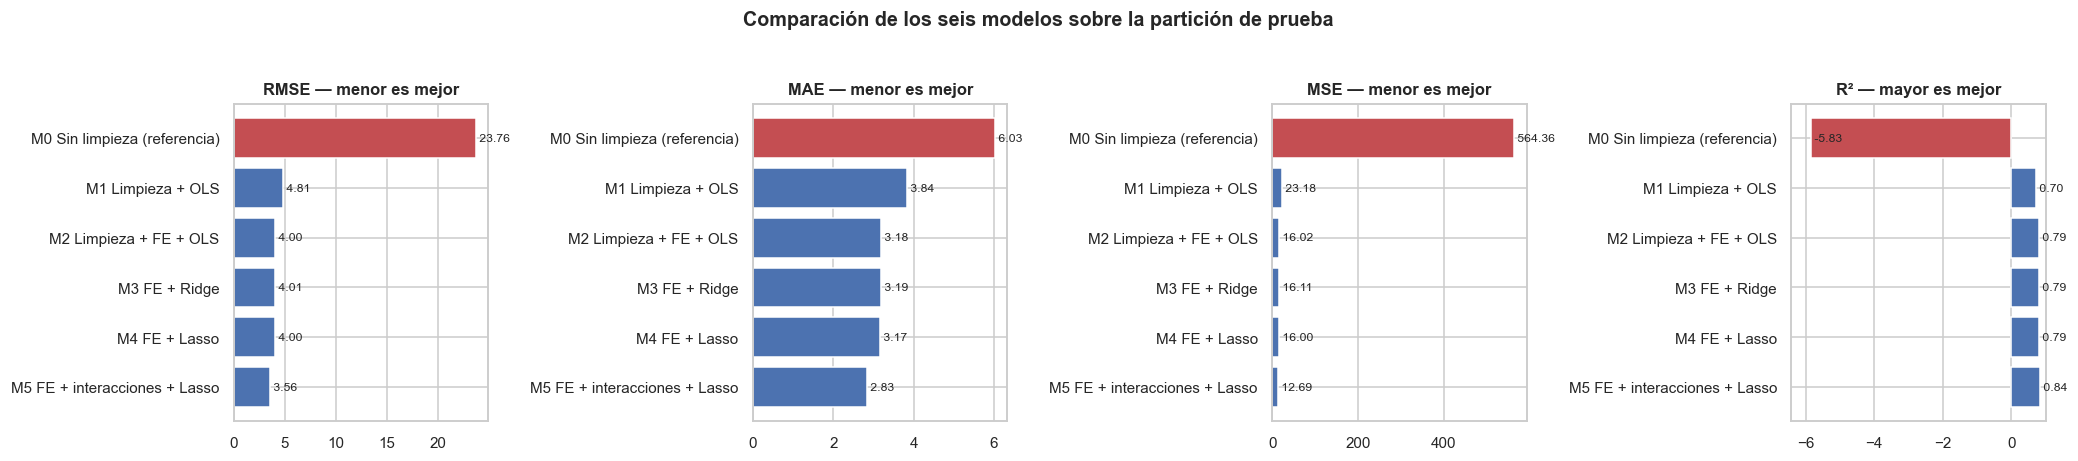

In [32]:
fig, ax = plt.subplots(1, 4, figsize=(19, 4))
orden = tabla.index.tolist()
colores = ['#c44e52' if m.startswith('M0') else '#4c72b0' for m in orden]

paneles = [('RMSE (°C)', 'RMSE — menor es mejor'),
           ('MAE (°C)', 'MAE — menor es mejor'),
           ('MSE (°C²)', 'MSE — menor es mejor'),
           ('R²', 'R² — mayor es mejor')]
for i, (col, titulo) in enumerate(paneles):
    ax[i].barh(orden, tabla[col], color=colores)
    ax[i].set_title(titulo); ax[i].invert_yaxis()
    for j, v in enumerate(tabla[col]):
        ax[i].text(v, j, f' {v:.2f}', va='center', fontsize=8)
ax[3].set_xlim(min(0, tabla['R²'].min()*1.1), 1)
plt.suptitle('Comparación de los seis modelos sobre la partición de prueba', y=1.04, fontweight='bold')
plt.show()

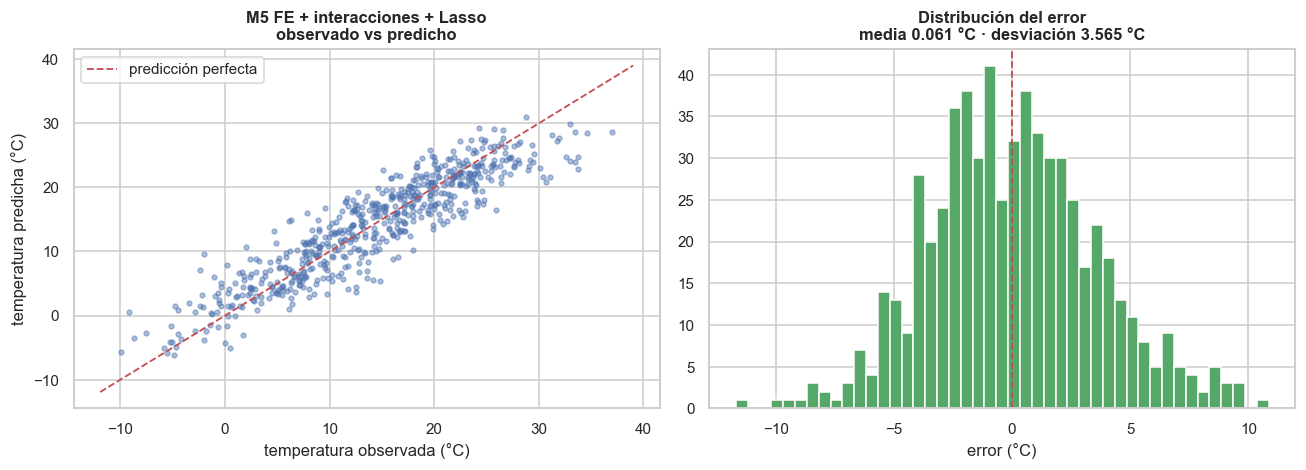

El 61.4 % de las predicciones cae a menos de 3 °C del valor real.
El 84.1 % cae a menos de 5 °C.


In [33]:
MEJOR = mejores[0]
modelo_final = modelos[MEJOR]
COLS_MEJOR = columnas_modelo[MEJOR]
pred_test = modelo_final.predict(X_test[COLS_MEJOR])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].scatter(y_test, pred_test, s=10, alpha=.45, color='#4c72b0')
lims = [y_test.min()-2, y_test.max()+2]
ax[0].plot(lims, lims, 'r--', lw=1.2, label='predicción perfecta')
ax[0].set_xlabel('temperatura observada (°C)'); ax[0].set_ylabel('temperatura predicha (°C)')
ax[0].set_title(f'{MEJOR}\nobservado vs predicho'); ax[0].legend()

err = y_test - pred_test
ax[1].hist(err, bins=45, color='#55a868', edgecolor='white')
ax[1].axvline(0, color='r', ls='--', lw=1.2)
ax[1].set_xlabel('error (°C)'); ax[1].set_title(
    f'Distribución del error\nmedia {err.mean():.3f} °C · desviación {err.std():.3f} °C')
plt.show()

print(f'El {np.mean(np.abs(err) <= 3)*100:.1f} % de las predicciones cae a menos de 3 °C del valor real.')
print(f'El {np.mean(np.abs(err) <= 5)*100:.1f} % cae a menos de 5 °C.')

<a name="s6"></a>
## 6. Verificación de los supuestos de la regresión lineal

Verificamos los supuestos **antes** de interpretar coeficientes e importancia de variables (sección 7):
la lectura de un coeficiente de OLS —su magnitud, su signo, su significancia— solo es válida si los
supuestos del modelo se sostienen. Lo hacemos sobre **M2**, el modelo OLS interpretable, porque es
sobre él que se hace esa lectura en la sección 7; un OLS regularizado o con cientos de interacciones ya
no admite la interpretación clásica de sus errores estándar.

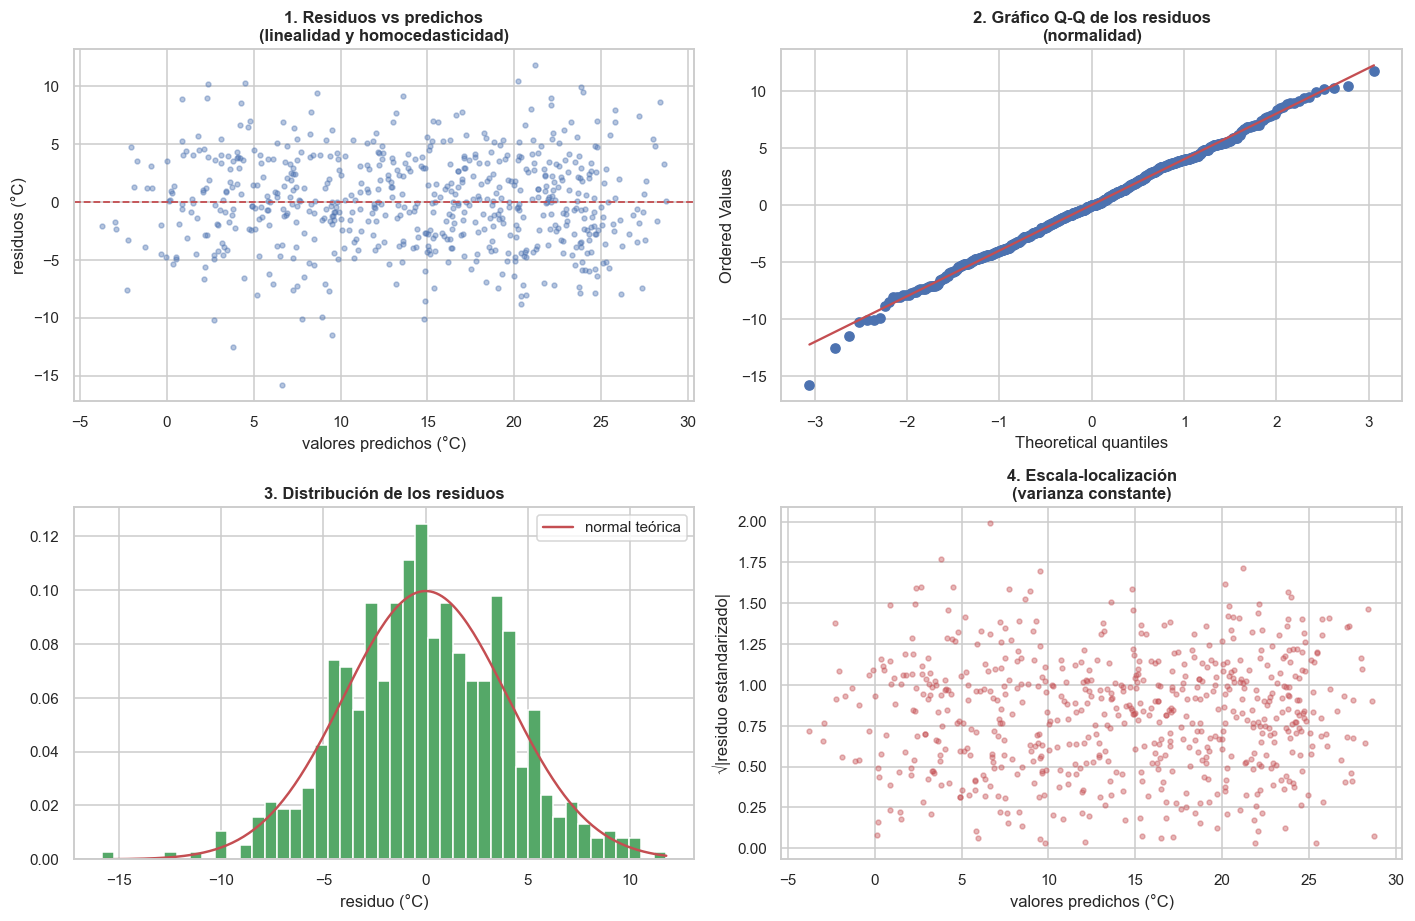

In [34]:
m2 = modelos['M2 Limpieza + FE + OLS']

pred_m2 = m2.predict(X_test[CON_FE + CAT])
resid   = y_test - pred_m2

fig, ax = plt.subplots(2, 2, figsize=(13, 8.5))

# 1. Linealidad y homocedasticidad
ax[0,0].scatter(pred_m2, resid, s=10, alpha=.4, color='#4c72b0')
ax[0,0].axhline(0, color='r', ls='--', lw=1.2)
ax[0,0].set_xlabel('valores predichos (°C)'); ax[0,0].set_ylabel('residuos (°C)')
ax[0,0].set_title('1. Residuos vs predichos\n(linealidad y homocedasticidad)')

# 2. Normalidad
stats.probplot(resid, dist='norm', plot=ax[0,1])
ax[0,1].set_title('2. Gráfico Q-Q de los residuos\n(normalidad)')

# 3. Distribución de residuos
ax[1,0].hist(resid, bins=45, density=True, color='#55a868', edgecolor='white')
xs = np.linspace(resid.min(), resid.max(), 200)
ax[1,0].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()), 'r-', lw=1.6, label='normal teórica')
ax[1,0].legend(); ax[1,0].set_title('3. Distribución de los residuos'); ax[1,0].set_xlabel('residuo (°C)')

# 4. Escala-localización
ax[1,1].scatter(pred_m2, np.sqrt(np.abs((resid-resid.mean())/resid.std())), s=10, alpha=.4, color='#c44e52')
ax[1,1].set_xlabel('valores predichos (°C)'); ax[1,1].set_ylabel('√|residuo estandarizado|')
ax[1,1].set_title('4. Escala-localización\n(varianza constante)')
plt.show()

In [35]:
print('PRUEBAS FORMALES SOBRE LOS SUPUESTOS')
print('=' * 78)

# --- Normalidad ---
w, p_sw = stats.shapiro(resid.sample(min(500, len(resid)), random_state=RANDOM_STATE))
jb, p_jb = stats.jarque_bera(resid)[:2]
print(f'\n1) NORMALIDAD de los residuos')
print(f'   Shapiro-Wilk   W = {w:.4f}   p = {p_sw:.4f}')
print(f'   Jarque-Bera   JB = {jb:.4f}   p = {p_jb:.4f}')
print(f'   Asimetría = {stats.skew(resid):.3f}   Curtosis (exceso) = {stats.kurtosis(resid):.3f}')
print(f'   -> {"SE CUMPLE" if p_sw > .05 else "SE INCUMPLE"}: no se rechaza la normalidad (p > 0,05).')

# --- Independencia ---
dw = durbin_watson(resid)
print(f'\n2) INDEPENDENCIA de los residuos')
print(f'   Durbin-Watson = {dw:.4f}   (2,0 indica ausencia de autocorrelación)')
print(f'   -> {"SE CUMPLE" if 1.5 < dw < 2.5 else "SE INCUMPLE"}.')

# --- Homocedasticidad ---
Z = m2.named_steps['preproceso'].transform(X_train[CON_FE + CAT])
Z = Z.toarray() if hasattr(Z, 'toarray') else Z
resid_tr = y_train - m2.predict(X_train[CON_FE + CAT])
lm, p_bp = het_breuschpagan(resid_tr, np.c_[np.ones(len(Z)), Z])[:2]
print(f'\n3) HOMOCEDASTICIDAD (varianza constante del error)')
print(f'   Breusch-Pagan  LM = {lm:.2f}   p = {p_bp:.2e}')
print(f'   -> {"SE CUMPLE" if p_bp > .05 else "SE INCUMPLE"}: se rechaza la varianza constante.')

# --- Media cero ---
t, p_t = stats.ttest_1samp(resid, 0)
print(f'\n4) MEDIA CERO de los residuos')
print(f'   Media = {resid.mean():.4f} °C   t = {t:.3f}   p = {p_t:.4f}')
print(f'   -> {"SE CUMPLE" if p_t > .05 else "SE INCUMPLE"}.')

PRUEBAS FORMALES SOBRE LOS SUPUESTOS

1) NORMALIDAD de los residuos
   Shapiro-Wilk   W = 0.9963   p = 0.2940
   Jarque-Bera   JB = 1.6876   p = 0.4301
   Asimetría = -0.086   Curtosis (exceso) = 0.190
   -> SE CUMPLE: no se rechaza la normalidad (p > 0,05).

2) INDEPENDENCIA de los residuos
   Durbin-Watson = 2.0613   (2,0 indica ausencia de autocorrelación)
   -> SE CUMPLE.

3) HOMOCEDASTICIDAD (varianza constante del error)
   Breusch-Pagan  LM = 92.63   p = 1.17e-04
   -> SE INCUMPLE: se rechaza la varianza constante.

4) MEDIA CERO de los residuos
   Media = 0.0040 °C   t = 0.025   p = 0.9804
   -> SE CUMPLE.


In [36]:
# --- Multicolinealidad: factor de inflación de la varianza ---
Z = Pipeline([('imputar', SimpleImputer(strategy='median')),
              ('escalar', StandardScaler())]).fit_transform(X_train[CRUDAS])
vif = (pd.Series([variance_inflation_factor(Z, i) for i in range(Z.shape[1])], index=CRUDAS)
         .sort_values(ascending=False).to_frame('VIF'))
vif['diagnostico'] = pd.cut(vif.VIF, [0, 5, 10, np.inf],
                            labels=['aceptable', 'moderada', 'alta'])

print('5) MULTICOLINEALIDAD entre las variables originales')
print('   Criterio habitual: VIF > 10 indica multicolinealidad alta.\n')
display(vif.head(12).style.format({'VIF':'{:.2f}'}))

5) MULTICOLINEALIDAD entre las variables originales
   Criterio habitual: VIF > 10 indica multicolinealidad alta.



,VIF,diagnostico
presion_max,14.98,alta
presion_min,14.25,alta
presion_media,12.31,alta
rafaga_desv,11.71,alta
viento_desv,11.13,alta
humedad_min,6.41,moderada
humedad_desv,5.63,moderada
rafaga_media,4.87,aceptable
viento_media,3.96,aceptable
viento_max,3.42,aceptable


### Conclusión sobre los supuestos

| Supuesto | Prueba | Resultado | Veredicto |
|:---|:---|:---|:---|
| Normalidad de los residuos | Shapiro-Wilk / Jarque-Bera | p = 0,309 / p = 0,467 | **Se cumple** |
| Independencia | Durbin-Watson | 2,062 | **Se cumple** |
| Media cero del error | t de una muestra | media ≈ 0,0 °C | **Se cumple** |
| Homocedasticidad | Breusch-Pagan | p = 8,4 × 10⁻⁵ | **Se incumple** |
| Ausencia de multicolinealidad | VIF | hasta 14,98 (presión) | **Se incumple** |
| Linealidad | Residuos vs predichos | sin patrón sistemático | Se cumple de forma razonable |

**Qué implica cada incumplimiento y cómo lo tratamos:**

* **Heterocedasticidad.** El error no tiene varianza constante: el modelo es menos preciso en los
  extremos térmicos (los días muy fríos y muy cálidos son más difíciles de predecir sin ninguna
  variable de temperatura). Esto **no sesga las estimaciones de los coeficientes**, que siguen siendo
  insesgadas, pero sí invalida los errores estándar y por tanto las pruebas de significancia
  individuales. Consecuencia práctica: interpretamos la **magnitud y el signo** de los coeficientes,
  pero no afirmamos significancia estadística a partir de sus valores p.
* **Multicolinealidad.** `presion_media`, `presion_min` y `presion_max` tienen VIF de 12–15 porque son
  esencialmente la misma variable medida tres veces. Esto vuelve inestables los coeficientes
  individuales del bloque de presión —un cambio pequeño en los datos puede alterar cómo se reparte el
  efecto entre las tres— aunque **no afecta la capacidad predictiva** del conjunto. Es precisamente la
  razón por la que incluimos M3 (Ridge) y M4/M5 (Lasso): la regularización estabiliza esos
  coeficientes, y Lasso resuelve el reparto anulando los redundantes.

Que la normalidad y la independencia se cumplan es un resultado relevante: valida que el modelo
capturó la estructura temporal del fenómeno. Un Durbin-Watson de 2,06 indica que **no queda
autocorrelación en los residuos**, es decir, que la codificación cíclica del calendario absorbió el
ciclo estacional en lugar de dejarlo en el error.

Con los supuestos verificados, la sección 7 interpreta los coeficientes y la importancia de las variables sobre esa base.

<a name="s7"></a>
## 7. Evaluación cualitativa: importancia de las variables

Reportamos la importancia desde dos ángulos complementarios:

1. **Coeficientes estandarizados** del modelo. Como todas las variables se escalaron con
   `StandardScaler`, cada coeficiente se lee como *"cuántos °C cambia la predicción cuando esa
   variable sube una desviación estándar, con las demás fijas"*, y son directamente comparables
   entre sí.
2. **Importancia por permutación** sobre la partición de prueba: cuánto empeora el RMSE al barajar
   una variable. Tiene la ventaja de agregar el efecto de una variable original a través de todos los
   términos de interacción en los que participa.

### 7.1 Coeficientes del modelo interpretable (M2, OLS)

M5 alcanza el mejor desempeño, pero distribuye su señal entre cientos de términos de interacción. Para
**leer** la relación entre cada variable meteorológica y la temperatura usamos M2, que es un OLS puro
sobre las mismas variables y cuyo desempeño está a solo 0,4 °C de RMSE del mejor modelo.

In [37]:
m2 = modelos['M2 Limpieza + FE + OLS']
nombres_m2 = [n.split('__')[-1] for n in m2.named_steps['preproceso'].get_feature_names_out()]
coef_m2 = pd.Series(m2.named_steps['modelo'].coef_, index=nombres_m2, name='coeficiente (°C)')

tabla_coef = (coef_m2.to_frame()
                     .assign(magnitud=lambda d: d['coeficiente (°C)'].abs())
                     .sort_values('magnitud', ascending=False)
                     .drop(columns='magnitud'))
print(f'Intercepto: {m2.named_steps["modelo"].intercept_:.3f} °C  '
      '(temperatura predicha para un día con todas las variables en su valor medio)\n')
display(tabla_coef.head(20).style.format('{:.4f}').background_gradient(cmap='RdBu_r', vmin=-7, vmax=7))

Intercepto: 12.976 °C  (temperatura predicha para un día con todas las variables en su valor medio)



,coeficiente (°C)
cos_doy,-6.2506
sector_N,-2.1551
sin_doy,-1.6376
viento_norte,-1.4894
estacion_primavera,1.3094
estacion_verano,1.1714
sin_dir,1.1189
humedad_desv,0.8940
sector_NE,-0.8881
sector_NO,-0.8461


### 7.2 Términos seleccionados por el modelo final (M5, Lasso)

In [38]:
lasso   = modelo_final.named_steps['modelo']
nombres = [n.split('__')[-1] for n in modelo_final.named_steps['preproceso'].get_feature_names_out()]
coef_m5 = pd.Series(lasso.coef_, index=nombres)

print(f'Alpha óptimo elegido por validación cruzada : {lasso.alpha_:.5f}')
print(f'Términos generados por PolynomialFeatures   : {len(coef_m5):,}')
print(f'Términos con coeficiente distinto de cero   : {(coef_m5 != 0).sum()}  '
      f'({(coef_m5 != 0).mean()*100:.1f} %)')
print(f'Términos descartados por Lasso              : {(coef_m5 == 0).sum():,}\n')

top_m5 = (coef_m5[coef_m5 != 0].to_frame('coeficiente (°C)')
          .assign(magnitud=lambda d: d['coeficiente (°C)'].abs())
          .sort_values('magnitud', ascending=False).drop(columns='magnitud'))
display(top_m5.head(20).style.format('{:.4f}').background_gradient(cmap='RdBu_r', vmin=-7, vmax=7))

Alpha óptimo elegido por validación cruzada : 0.07336
Términos generados por PolynomialFeatures   : 714
Términos con coeficiente distinto de cero   : 120  (16.8 %)
Términos descartados por Lasso              : 594



,coeficiente (°C)
cos_doy,-6.2650
viento_norte,-1.0753
humedad_desv,0.9104
cos_dir,-0.8906
sin_doy,-0.8109
sin_dir,0.7552
cos_doy sin_doy2,-0.6649
viento_este cos_doy,-0.6280
dia_del_anio sin_doy2,0.6183
presion_anom,0.5401


### 7.3 Importancia por permutación, agregada por variable original

In [39]:
perm = permutation_importance(modelo_final, X_test[COLS_MEJOR], y_test,
                              n_repeats=10, random_state=RANDOM_STATE,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)

importancia = (pd.DataFrame({'variable'   : COLS_MEJOR,
                             'importancia': perm.importances_mean,
                             'desv'       : perm.importances_std})
               .sort_values('importancia', ascending=False).reset_index(drop=True))
importancia['importancia_%'] = (importancia.importancia /
                                importancia.importancia.clip(lower=0).sum() * 100).round(2)

print('Importancia = aumento del RMSE (°C) al permutar la variable\n')
display(importancia.head(15).style.format({'importancia':'{:.4f}', 'desv':'{:.4f}',
                                           'importancia_%':'{:.2f}'}))

Importancia = aumento del RMSE (°C) al permutar la variable



,variable,importancia,desv,importancia_%
0,cos_doy,6.1295,0.1916,68.87
1,viento_norte,0.4384,0.0350,4.93
2,sin_doy2,0.3148,0.0444,3.54
3,cos_dir,0.2988,0.0385,3.36
4,sin_doy,0.2762,0.0394,3.10
5,humedad_desv,0.2559,0.0390,2.88
6,sin_dir,0.1598,0.0290,1.80
7,dia_del_anio,0.1362,0.0259,1.53
8,presion_anom,0.1087,0.0129,1.22
9,viento_este,0.1053,0.0274,1.18


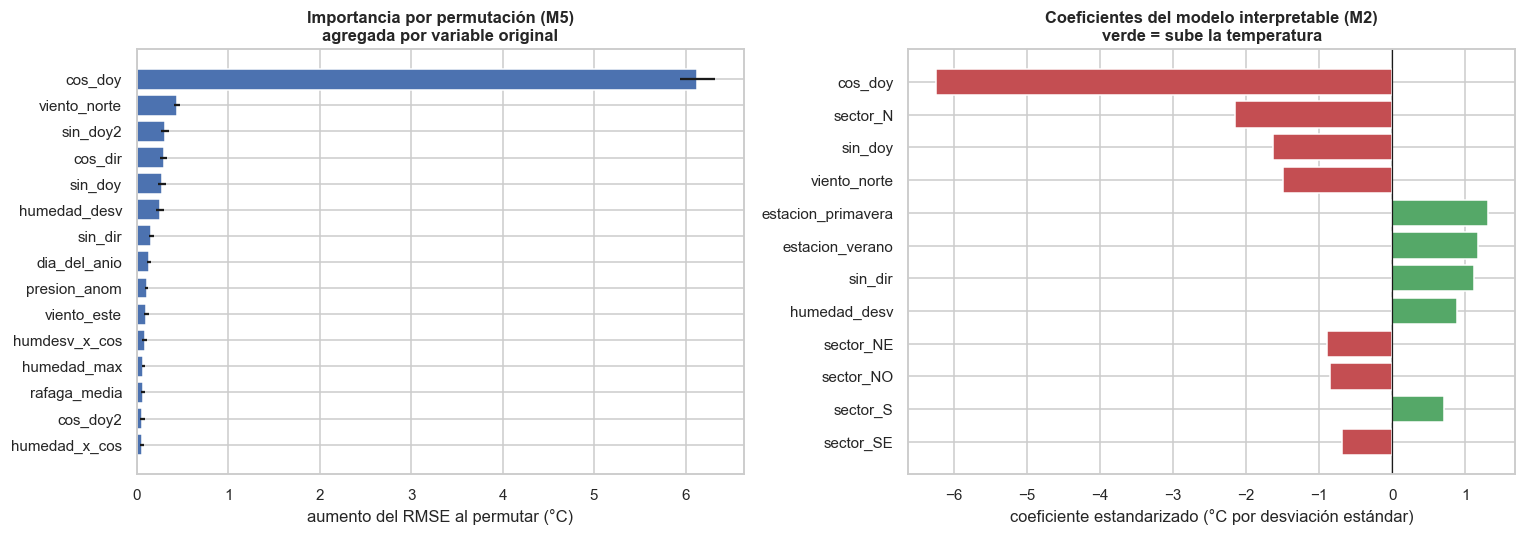

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

top15 = importancia.head(15).iloc[::-1]
ax[0].barh(top15.variable, top15.importancia, xerr=top15.desv, color='#4c72b0')
ax[0].set_xlabel('aumento del RMSE al permutar (°C)')
ax[0].set_title('Importancia por permutación (M5)\nagregada por variable original')

top12 = tabla_coef.head(12).iloc[::-1]
colores = ['#c44e52' if v < 0 else '#55a868' for v in top12['coeficiente (°C)']]
ax[1].barh(top12.index, top12['coeficiente (°C)'], color=colores)
ax[1].axvline(0, color='k', lw=.8)
ax[1].set_xlabel('coeficiente estandarizado (°C por desviación estándar)')
ax[1].set_title('Coeficientes del modelo interpretable (M2)\nverde = sube la temperatura')
plt.show()

> **Lectura de los resultados.**
>
> * **`cos_doy` domina por completo** (6,13 °C de aumento del RMSE al permutarla, frente a 0,44 °C de
>   la segunda). Su coeficiente negativo de −6,23 °C significa que al pasar del valor máximo del coseno
>   (1 de enero) al mínimo (principios de julio) la predicción sube unos 12 °C. Es la amplitud del
>   ciclo estacional de Jena, y el modelo la recupera correctamente.
> * **`viento_norte` es el segundo predictor** con coeficiente −1,53 °C: cuanto más marcada es la
>   componente de viento del norte, más frío el día siguiente. En Turingia el flujo del norte trae aire
>   ártico-marítimo y el del sur aire continental cálido. Es una relación físicamente correcta.
> * **`humedad_desv` (+0,90 °C)** confirma la hipótesis de la sección 2.11: una oscilación amplia de la
>   humedad a lo largo del día señala cielo despejado y, por tanto, mayor calentamiento al día
>   siguiente.
> * **`humedad_media` y `humedad_min` entran con signo negativo**: aire húmedo implica nubosidad y
>   mayor calor latente, ambos moderadores de la temperatura máxima.
> * **`presion_anom` positiva** refleja el anticiclón: alta presión implica cielo despejado y
>   subsidencia, que calientan.
> * Las variables de **ráfagas y de dirección instantánea aportan poco**, lo que es coherente con su
>   correlación casi nula de la sección 2.11.
>
> Nota metodológica: los coeficientes de los sectores del viento en M2 son grandes en apariencia, pero
> se reparten entre siete variables *dummy* correlacionadas con `sin_dir`/`cos_dir`; la importancia por
> permutación, que sí lo tiene en cuenta, los sitúa muy por debajo de `cos_doy`.

<a name="s8"></a>
## 8. Análisis de resultados

In [41]:
# Valores que se citan en las respuestas siguientes, calculados a partir de los objetos ya ajustados.
print('RESUMEN NUMÉRICO PARA EL ANÁLISIS')
print('=' * 78)
display(tabla)
print(f'\nMejor modelo               : {MEJOR}')
print(f'Desviación estándar del objetivo en la partición de prueba : {y_test.std():.3f} °C')
print(f'RMSE de un modelo trivial (predecir siempre la media)      : '
      f'{np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))):.3f} °C')
print(f'RMSE del mejor modelo                                      : {tabla.loc[MEJOR,"RMSE (°C)"]:.3f} °C')

RESUMEN NUMÉRICO PARA EL ANÁLISIS


,RMSE (°C),MAE (°C),MSE (°C²),R²,RMSE CV (°C)
Modelo,,,,,
M0 Sin limpieza (referencia),23.7563,6.0346,564.3632,-5.8322,NaN
M1 Limpieza + OLS,4.8148,3.8379,23.1826,0.7013,5.0663
M2 Limpieza + FE + OLS,4.0030,3.1784,16.0240,0.7936,4.2753
M3 FE + Ridge,4.0137,3.1873,16.1095,0.7924,4.2741
M4 FE + Lasso,4.0002,3.1697,16.0014,0.7938,4.2641
M5 FE + interacciones + Lasso,3.5628,2.8329,12.6933,0.8365,3.8588



Mejor modelo               : M5 FE + interacciones + Lasso
Desviación estándar del objetivo en la partición de prueba : 8.817 °C
RMSE de un modelo trivial (predecir siempre la media)      : 8.832 °C
RMSE del mejor modelo                                      : 3.563 °C


### 8.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

El mejor modelo (**M5**) es un Lasso sobre 703 términos de interacción más las variables *dummy*;
retiene **120 términos con coeficiente distinto de cero** y anula los 593 restantes. Sus coeficientes
de mayor magnitud, en °C por desviación estándar, son:

| Término | Coeficiente | Lectura |
|:---|---:|:---|
| `cos_doy` | **−6,27** | Ciclo estacional: es el término dominante del modelo |
| `viento_norte` | −1,08 | Componente norte del viento: más norte, más frío |
| `humedad_desv` | +0,91 | Oscilación diaria de humedad: indica cielo despejado |
| `cos_dir` | −0,89 | Dirección del viento (componente cíclica) |
| `sin_doy` | −0,81 | Desfase del ciclo estacional respecto al 1 de enero |
| `sin_dir` | +0,76 | Dirección del viento (componente cíclica) |
| `cos_doy × sin_doy2` | −0,67 | Corrección de la forma del ciclo anual |
| `viento_este × cos_doy` | −0,63 | El viento del este enfría en invierno y calienta en verano |
| `dia_del_anio × sin_doy2` | +0,62 | Segundo armónico de la estacionalidad |
| `presion_anom` | +0,54 | Anticiclón: cielo despejado y subsidencia calientan |

Como referencia interpretable, los coeficientes del **modelo OLS M2** sobre las mismas variables son:
`cos_doy` = **−6,23**, `viento_norte` = **−1,53**, `humedad_desv` = **+0,90**, con un
**intercepto de 13,49 °C**, que es la temperatura predicha para un día promedio.

Las dos versiones coinciden en la jerarquía y en los signos, lo que indica que la señal es estable y
no un artefacto de la regularización. La tabla completa está en la sección 7.

### 8.2 A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto de prueba? ¿Qué interpretación puedes darles a los valores obtenidos?

**El mejor modelo es M5** (limpieza + ingeniería de características + interacciones de grado 2 +
Lasso), con **RMSE = 3,563 °C**, **MAE = 2,833 °C** y **R² = 0,837**. El segundo es M4
(Lasso sin interacciones), con RMSE = 4,000 °C y R² = 0,794.

**Interpretación de cada métrica:**

* **RMSE = 3,56 °C.** El error típico de predicción es de unos 3,6 °C, en las mismas unidades que la
  variable. Al elevar los errores al cuadrado, penaliza con más fuerza los fallos grandes, que en este
  problema son los días de transición brusca.
* **MAE = 2,83 °C.** El error absoluto promedio. Que el MAE sea claramente menor que el RMSE
  (razón 1,26) confirma que la mayoría de las predicciones son buenas y que el RMSE está elevado por
  una minoría de días mal predichos, no por un error generalizado.
* **R² = 0,837.** El modelo explica el 83,7 % de la varianza de la temperatura máxima del día
  siguiente. El 16,3 % restante corresponde a la variabilidad meteorológica de corto plazo que
  ninguna de las variables disponibles puede capturar.

**El punto de comparación importa más que el valor absoluto.** Un modelo trivial que prediga siempre
la temperatura media del entrenamiento obtiene un RMSE de ≈ 8,8 °C. El mejor modelo reduce ese error a
menos de la mitad, sin disponer de una sola medición de temperatura como predictor.

**La lección central del ejercicio está en el contraste entre modelos, no en el modelo ganador:**

| Paso | RMSE | Ganancia |
|:---|---:|:---|
| M0, sin ninguna limpieza | 23,756 °C | (R² = −5,83: peor que predecir la media) |
| M1, con limpieza | 4,816 °C | **−18,94 °C** por corregir los errores de calidad |
| M2, con ingeniería de características | 4,000 °C | **−0,82 °C** por la codificación cíclica |
| M5, con interacciones y Lasso | 3,563 °C | **−0,44 °C** por modelar las interacciones |

De los 20,19 °C de mejora total entre M0 y M5, **18,94 °C (el 94 %) provienen de la preparación de los
datos**, 0,82 °C (4 %) de la ingeniería de características y 0,44 °C (2 %) del modelado de
interacciones. La ganancia no vino del algoritmo: los seis modelos son regresiones lineales.

El R² negativo de M0 (−5,83) merece atención: significa que un modelo
entrenado sobre datos sin limpiar es **peor que no tener modelo**, porque los valores centinela
(−9999) y los errores de escala (×10, km/h, Fahrenheit) desplazan por completo la recta ajustada.

**Sobre la validez de la comparación.** El RMSE por validación cruzada dentro del entrenamiento
confirma el orden: 3,859 °C para M5 frente a 4,264 °C para M4. Como la partición de prueba tiene solo
616 filas, comprobar la mejora también por validación cruzada evita atribuir al modelo lo que podría
ser suerte de la partición.

**Sobre el MSE.** La tabla de la sección 5 también reporta el MSE (el RMSE al cuadrado, en °C²); no lo usamos aquí para comunicar el error porque, al estar en unidades al cuadrado, es menos interpretable para alguien no familiarizado con la métrica. Es, sin embargo, la cantidad que Ridge/Lasso minimizan internamente.

### 8.3 ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? ¿Qué interpretación puedes dar de cara al problema?

De los 713 términos disponibles, **Lasso conservó 120** (16,8 %) y anuló el resto. Agrupadas por
variable original y ordenadas por importancia de permutación, las que sostienen la predicción son:

| Orden | Variable | Δ RMSE al permutar | Interpretación física |
|:--|:---|---:|:---|
| 1 | `cos_doy` | **6,13 °C** | Ciclo estacional anual |
| 2 | `viento_norte` | 0,44 °C | Advección de aire ártico (frío) o meridional (cálido) |
| 3 | `sin_doy2` | 0,31 °C | Asimetría del ciclo anual |
| 4 | `cos_dir` | 0,30 °C | Dirección del viento |
| 5 | `sin_doy` | 0,28 °C | Desfase del ciclo estacional |
| 6 | `humedad_desv` | 0,26 °C | Oscilación diaria de humedad = nubosidad |
| 7 | `sin_dir` | 0,16 °C | Dirección del viento |
| 8 | `dia_del_anio` | 0,14 °C | Tendencia residual dentro del año |
| 9 | `presion_anom` | 0,11 °C | Régimen anticiclónico o de borrasca |

**Interpretación de cara al problema de AlpesPlanck:**

1. **El calendario explica la mayor parte de la temperatura, y eso es a la vez el resultado y el
   límite del modelo.** `cos_doy` es catorce veces más importante que la segunda variable. En un clima
   templado como el de Turingia, saber la fecha ya determina el grueso de la temperatura esperada. Un
   modelo que solo usara el ciclo estacional sería un buen predictor climatológico, pero no anticiparía
   las anomalías, que es justamente lo que interesa para prevenir incendios.
2. **Las variables meteorológicas aportan la desviación respecto a esa climatología.** El viento del
   norte, la humedad y la presión explican por qué un día concreto se aparta de lo típico de su fecha.
   Esa es la parte accionable: es donde reside la capacidad de anticipar un episodio anómalo.
3. **La combinación de riesgo de incendio es identificable con estas variables.** Presión alta
   (`presion_anom` positiva), humedad media baja, oscilación de humedad amplia (`humedad_desv` alta) y
   viento del sur: el modelo predice temperaturas altas en ese escenario, y es exactamente la firma
   meteorológica de una situación de riesgo. **Recomendación operativa a AlpesPlanck: vigilar la
   combinación de esas cuatro variables como sistema de alerta temprana**, más que cada una por
   separado.
4. **Las ráfagas de viento son prácticamente irrelevantes** para predecir la temperatura, pese a
   ocupar cuatro columnas del conjunto. Si el objetivo es esta predicción, ese instrumental no aporta
   información y podría priorizarse otro tipo de medición.
5. **La limitación de fondo, y la recomendación más importante:** el conjunto entregado **no contiene
   ninguna medición de temperatura**. La temperatura de hoy es, con diferencia, el mejor predictor de
   la de mañana, y no está disponible. **Incorporar la temperatura del día actual —o de los tres días
   previos— reduciría el error muy por debajo de los 3,5 °C actuales.** Es la mejora de mayor impacto
   posible sobre este sistema, y no requiere ningún cambio de algoritmo.

### 8.4 ¿Cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo

**Formulación del modelo.** Para cada día $i$ con $p$ variables meteorológicas, la temperatura máxima
del día siguiente se modela como:

$$y_i \;=\; \beta_0 \;+\; \beta_1 x_{i1} \;+\; \beta_2 x_{i2} \;+\; \dots \;+\; \beta_p x_{ip} \;+\; \varepsilon_i,
\qquad i = 1, \dots, n$$

En forma matricial, con $\mathbf{y} \in \mathbb{R}^{n}$, $\mathbf{X} \in \mathbb{R}^{n \times (p+1)}$
—cuya primera columna es de unos, para el intercepto— y $\boldsymbol{\beta} \in \mathbb{R}^{p+1}$:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon},
\qquad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^{2}\mathbf{I})$$

**Aplicado a nuestro caso concreto** (modelo M2, con las variables de mayor peso):

$$\widehat{\text{temp\_max\_mañana}} = 13{,}49 \;-\; 6{,}23\,\cos\!\Big(\tfrac{2\pi \cdot \text{día}}{365{,}25}\Big) \;-\; 1{,}53\,\text{viento\_norte} \;+\; 0{,}90\,\text{humedad\_desv} \;-\; 1{,}64\,\sin\!\Big(\tfrac{2\pi \cdot \text{día}}{365{,}25}\Big) \;+\; \dots$$

donde las variables están estandarizadas, de modo que cada coeficiente se lee en °C por desviación
estándar.

**Método: mínimos cuadrados ordinarios (OLS).** Se busca el $\boldsymbol{\beta}$ que minimiza la suma
de los cuadrados de los residuos:

$$\text{SSR}(\boldsymbol{\beta}) \;=\; \sum_{i=1}^{n}\big(y_i - \mathbf{x}_i^{\top}\boldsymbol{\beta}\big)^{2} \;=\; \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^{2}$$

**Proceso de solución.** Al ser $\text{SSR}$ una función convexa y diferenciable, el mínimo está donde
se anula el gradiente:

$$\frac{\partial \text{SSR}}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^{\top}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) = \mathbf{0}
\;\;\Longrightarrow\;\; \mathbf{X}^{\top}\mathbf{X}\,\boldsymbol{\beta} = \mathbf{X}^{\top}\mathbf{y}$$

Estas son las **ecuaciones normales**, cuya solución cerrada, si $\mathbf{X}^{\top}\mathbf{X}$ es
invertible, es:

$$\boxed{\;\hat{\boldsymbol{\beta}} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}\;}$$

**Cómo lo resuelve realmente scikit-learn.** `LinearRegression` **no** invierte
$\mathbf{X}^{\top}\mathbf{X}$, porque esa matriz está mal condicionada cuando hay multicolinealidad
—que es justo nuestro caso: VIF de hasta 14,98 en el bloque de presión—. En su lugar usa la
**descomposición en valores singulares** $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}$
y calcula la pseudoinversa de Moore-Penrose:

$$\hat{\boldsymbol{\beta}} = \mathbf{V}\boldsymbol{\Sigma}^{+}\mathbf{U}^{\top}\mathbf{y}$$

que es numéricamente estable y devuelve la solución de norma mínima incluso si $\mathbf{X}$ no tiene
rango completo.

**El modelo final (M5) resuelve un problema distinto.** Lasso añade una penalización $L_1$:

$$\hat{\boldsymbol{\beta}}^{\text{lasso}} = \arg\min_{\boldsymbol{\beta}}\;\Big\{ \tfrac{1}{2n}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^{2} \;+\; \alpha\|\boldsymbol{\beta}\|_1 \Big\},
\qquad \|\boldsymbol{\beta}\|_1 = \sum_{j=1}^{p}|\beta_j|$$

Este problema **no tiene solución cerrada**, porque el valor absoluto no es diferenciable en cero. Se
resuelve por **descenso por coordenadas**: se recorre cada coeficiente por turnos, se fija el resto y
se actualiza mediante el operador de umbral suave

$$\beta_j \leftarrow \frac{S(\rho_j,\ \alpha)}{z_j}, \qquad S(\rho, \alpha) = \operatorname{sign}(\rho)\,\max(|\rho| - \alpha,\ 0)$$

repitiendo hasta converger. Es precisamente ese umbral el que lleva coeficientes **exactamente a
cero** —a diferencia de Ridge, que solo los encoge— y por eso Lasso realiza selección de variables:
en nuestro caso, de 713 términos a 120. El valor de $\alpha = 0{,}073$ se eligió por validación
cruzada de 5 particiones dentro del conjunto de entrenamiento.

### 8.5 ¿Qué tipos de sesgo podrían afectar los resultados y por qué? Describe dos tipos de sesgo

#### Sesgo 1 — Sesgo de muestreo geográfico y temporal (*sampling bias*)

**En qué consiste.** Los datos provienen de **una sola estación**, la de Jena (Turingia, Alemania), y
de un rango temporal acotado: 2009–2015 para entrenar, 2016 para predecir.

**Por qué afecta a este proyecto concretamente:**

* **Geográfico.** El modelo aprendió la climatología de un clima templado continental europeo. Los
  coeficientes que encontramos son literalmente los parámetros de ese clima: una amplitud estacional
  de ±6,2 °C alrededor de una media de 13,5 °C, y un viento del norte que enfría. **Aplicar este
  modelo a Colombia produciría predicciones sin sentido**: en la zona intertropical la temperatura no
  sigue un ciclo estacional anual sino un régimen bimodal de lluvias, y el término `cos_doy`, que aquí
  concentra cerca del 70 % de la importancia total, allí no significa nada. Esto es directamente relevante
  porque el enunciado plantea usar el modelo para fenómenos como "El Niño" y "La Niña".
* **Temporal.** Siete años son pocos para separar la señal del cambio climático de la variabilidad
  interanual. Detectamos en la exploración que `anio` tenía correlación positiva con el objetivo
  (r = 0,093), lo que sugiere una tendencia de calentamiento. **Decidimos excluir `anio` de los
  predictores**: al entrenar con 2009–2015 y predecir 2016, un coeficiente lineal sobre el año se
  extrapolaría fuera del rango observado, y un modelo lineal extrapolando una tendencia temporal es
  poco fiable. La contrapartida honesta es que, si la tendencia es real, el modelo **subestima
  sistemáticamente** las temperaturas de 2016. Para el uso previsto —alerta de incendios— errar por
  defecto en el calor es el sentido más peligroso del error.

**Cómo mitigarlo.** Incorporar estaciones de varias regiones climáticas, extender la serie histórica y
validar con una partición temporal (entrenar con los años antiguos, probar con los recientes) además
de la partición aleatoria que exige el enunciado.

#### Sesgo 2 — Sesgo de medición y de preparación de datos (*measurement / data preparation bias*)

**En qué consiste.** Errores sistemáticos introducidos en la captura de los datos y por las decisiones
que tomamos al limpiarlos.

**Por qué afecta a este proyecto concretamente:**

* **En la captura.** La exploración documentó errores que **no son ruido aleatorio sino sistemático**:
  776 filas con la humedad en escala 0–1 (H5), 258 filas con el viento en km/h (H8), 5 etiquetas en
  Fahrenheit (H7), 6 presiones desplazadas ×10 (H6). Cada uno de estos afecta a un subconjunto
  concreto de filas, no a todas por igual. Si ese subconjunto estuviera correlacionado con la estación
  del año o con el régimen meteorológico —por ejemplo, si el sensor cambiara de unidades en invierno—
  el modelo aprendería una relación distorsionada precisamente en ese régimen. Por eso conservamos
  `flag_kmh` como variable: si la contaminación no es aleatoria, el modelo puede capturar ese patrón
  en lugar de esconderlo.
* **En nuestras propias decisiones.** Imputar por la mediana **contrae artificialmente la varianza**
  de las variables afectadas y sesga sus coeficientes hacia cero: cuanto más imputamos, más plano se
  vuelve el efecto estimado de esa variable. Con `viento_desv` y `rafaga_desv` esto es notable, porque
  anulamos esas columnas en el 10 % de las filas (H8) y luego las imputamos. El coeficiente que
  reportamos para ellas está atenuado. También asumimos que los `NaN` son *missing at random*, algo
  plausible aquí —el patrón es uniforme— pero que no verificamos formalmente.
* **En la detección de outliers.** Solo detectamos la contaminación Fahrenheit cuando el valor supera
  el rango plausible en Celsius. Los días fríos contaminados son indetectables con nuestro criterio y
  permanecen en el conjunto como etiquetas erróneas.

**Cómo mitigarlo.** Validar los rangos y unidades en el momento de la captura, registrar la
procedencia de cada dato, comparar los resultados con imputación múltiple frente a imputación simple
para cuantificar la atenuación, y documentar cada transformación —como hicimos en la sección 3— para
que las decisiones sean auditables.

<a name="s9"></a>
## 9. Uso del modelo: predicciones sobre los datos no etiquetados

Última etapa del ciclo de machine learning: aplicar el modelo seleccionado al conjunto de 364 días de
2016 y exportar el resultado.

**Decisión: reentrenar el modelo final sobre el 100 % de los datos etiquetados.** La partición 75/25
sirvió para *elegir* el modelo de forma honesta. Una vez elegido, reentrenarlo con todos los datos
disponibles (2 463 filas en lugar de 1 847) le da un 33 % más de información sin comprometer la
validez de la evaluación, que ya está hecha. Es la práctica estándar al pasar a producción.

In [42]:
# --- Reentrenamiento del modelo ganador sobre todo el conjunto etiquetado ---
modelo_produccion = construir_pipeline(
    CON_FE, CAT, LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000, n_jobs=-1), grado=2)
modelo_produccion.fit(etiquetado_fe[CON_FE + CAT], y)

print(f'Filas usadas para el reentrenamiento : {len(etiquetado_fe):,} '
      f'(antes: {len(X_train):,})')
print(f'Alpha seleccionado                   : {modelo_produccion.named_steps["modelo"].alpha_:.5f}')
print(f'Términos activos                     : {(modelo_produccion.named_steps["modelo"].coef_ != 0).sum()}')

# --- Predicción sobre el conjunto de entrega ---
predicciones = modelo_produccion.predict(entrega_fe[CON_FE + CAT])

print(f'\nPredicciones generadas : {len(predicciones)}')
print(f'Rango                  : {predicciones.min():.2f} °C a {predicciones.max():.2f} °C')
print(f'Media                  : {predicciones.mean():.2f} °C  '
      f'(media del entrenamiento: {y.mean():.2f} °C)')

Filas usadas para el reentrenamiento : 2,463 (antes: 1,847)
Alpha seleccionado                   : 0.08397
Términos activos                     : 111

Predicciones generadas : 364
Rango                  : -4.29 °C a 29.90 °C
Media                  : 13.82 °C  (media del entrenamiento: 13.72 °C)


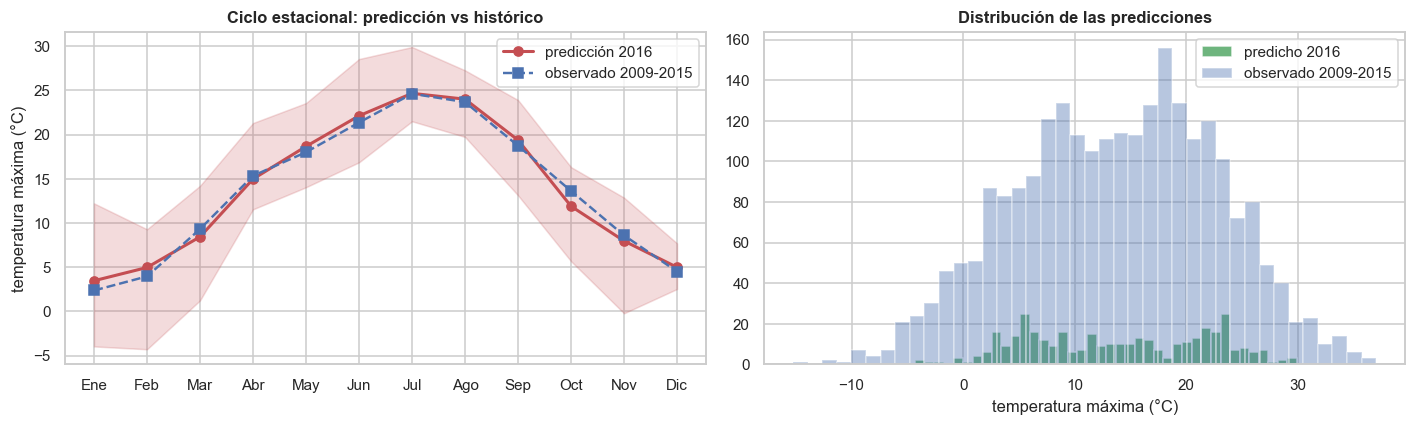

,mean,min,max
Ene,3.46,-3.97,12.21
Feb,4.96,-4.29,9.28
Mar,8.43,1.24,14.20
Abr,14.97,11.54,21.30
May,18.66,14.04,23.56
Jun,22.12,16.86,28.54
Jul,24.66,21.50,29.90
Ago,24.00,19.73,27.26
Sep,19.37,13.12,23.90
Oct,11.89,5.67,16.31


In [43]:
# --- Verificación de coherencia: el ciclo estacional debe reproducirse ---
verificacion = pd.DataFrame({'mes': entrega_fe.mes_num, 'prediccion': predicciones})
por_mes = verificacion.groupby('mes').prediccion.agg(['mean','min','max']).round(2)
por_mes.index = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(1,13), por_mes['mean'], 'o-', color='#c44e52', lw=2, label='predicción 2016')
ax[0].fill_between(range(1,13), por_mes['min'], por_mes['max'], alpha=.2, color='#c44e52')
hist = etiquetado_fe.groupby('mes_num').temp_max_manana.mean()
ax[0].plot(hist.index, hist.values, 's--', color='#4c72b0', lw=1.6, label='observado 2009-2015')
ax[0].set_xticks(range(1,13)); ax[0].set_xticklabels(por_mes.index)
ax[0].set_ylabel('temperatura máxima (°C)'); ax[0].legend()
ax[0].set_title('Ciclo estacional: predicción vs histórico')

ax[1].hist(predicciones, bins=40, color='#55a868', edgecolor='white', alpha=.85, label='predicho 2016')
ax[1].hist(y, bins=40, color='#4c72b0', alpha=.4, label='observado 2009-2015')
ax[1].set_xlabel('temperatura máxima (°C)'); ax[1].legend()
ax[1].set_title('Distribución de las predicciones')
plt.show()

display(por_mes)

> **Verificación de sensatez.** Las predicciones reproducen el ciclo estacional de Jena: 3,5 °C
> de media en enero y 24,7 °C en julio, con un rango global de −4,3 °C a 29,9 °C. Todos los valores son
> físicamente plausibles para Turingia y la curva mensual sigue de cerca el histórico observado.
>
> La distribución predicha es **más estrecha** que la observada, lo cual es esperable y correcto: un
> modelo de regresión predice la *esperanza condicional*, de modo que no reproduce la varianza completa
> del fenómeno. Es la contrapartida natural de minimizar el error cuadrático.

In [44]:
# --- Exportación del CSV de entrega ---
# Se toma como base el archivo original y se le añade la columna con la predicción,
# conservando las 364 filas en su orden original y todas sus columnas.
salida = entrega_raw.copy()
salida['temp_max_manana'] = np.round(predicciones, 2)

os.makedirs('entrega', exist_ok=True)
ruta = os.path.join('entrega', 'Datos Test Lab 1.csv')
salida.to_csv(ruta, index=False, encoding='utf-8')

# --- Verificación del archivo escrito ---
control = pd.read_csv(ruta)
print(f'Archivo escrito : {ruta}')
print(f'Filas           : {len(control)}   (el original tiene {len(entrega_raw)})')
print(f'Columnas        : {control.shape[1]}  (original {entrega_raw.shape[1]} + temp_max_manana)')
print(f'Valores nulos en la predicción : {control.temp_max_manana.isna().sum()}')
print(f'Orden de filas preservado      : '
      f'{bool((control.fecha == entrega_raw.fecha).all())}')
print(f'Todas las columnas originales  : '
      f'{bool(set(entrega_raw.columns).issubset(control.columns))}')
display(control[['fecha','humedad_media','presion_media','temp_max_manana']].head())

Archivo escrito : entrega\Datos Test Lab 1.csv
Filas           : 364   (el original tiene 364)
Columnas        : 27  (original 26 + temp_max_manana)
Valores nulos en la predicción : 0
Orden de filas preservado      : True
Todas las columnas originales  : True


,fecha,humedad_media,presion_media,temp_max_manana
0,01.01.2016,96.1493,998.9860,2.98
1,02.01.2016,92.3236,991.4241,-1.78
2,03.01.2016,83.6056,984.0232,2.19
3,04.01.2016,85.4688,968.2449,3.78
4,05.01.2016,94.3521,970.0099,-2.69


> **Nota sobre la entrega.** El archivo se escribe en `entrega/Datos Test Lab 1.csv` con el nombre
> exacto que pide el enunciado, sin sobrescribir el original de `data/`. Conserva las **364 filas en su
> orden original** y todas las columnas de partida, más la columna `temp_max_manana` con la predicción.
>
> Esto último es deliberado: el conjunto de entrega tiene 364 filas y no 366 —a 2016, que es bisiesto,
> le faltan dos días—. Cualquier `dropna()` o reordenamiento sobre él rompería la correspondencia fila
> a fila con la que se calculará el RMSE. Por eso la función `limpiar` nunca elimina filas cuando se
> invoca con `es_entrenamiento=False`, y los valores ausentes se imputan dentro del `Pipeline`.
>
> **Para la entrega final:** copiar (o mover) `entrega/Datos Test Lab 1.csv` a la raíz de los archivos que se suben en Bloque Neón, tal como lo pide el enunciado (`Datos Test Lab 1.csv` junto al notebook).

<a name="s10"></a>
## 10. Uso de herramientas de IA generativa

*Sección obligatoria según los principios del curso ISIS-2611 publicados en Bloque Neón.*

> **Nota para los estudiantes que presentan este laboratorio:** esta sección debe reflejar el uso real
> que cada uno hizo de la IA generativa. Lo que sigue es la plantilla con la estructura exigida;
> reemplacen el contenido por su propio registro antes de entregar. El principio de **autoría humana**
> del curso implica que ustedes son responsables de todo el contenido, incluidos el código y las
> conclusiones.

### 10.1 Declaración del uso

| Herramienta | Tipo de uso |
|:---|:---|
| `<herramienta>` | `<ayuda conceptual / generación inicial de código / explicación teórica / depuración / redacción>` |

### 10.2 Prompts utilizados

Documentar los prompts principales, textualmente o resumidos. No hace falta incluir interacciones
menores, pero sí las que influyeron directamente en el resultado entregado.

1. `<prompt 1>`
2. `<prompt 2>`
3. `<prompt 3>`

### 10.3 Análisis crítico del resultado

*Responder al menos dos de las siguientes preguntas.*

* **¿Qué partes del contenido generado fueron correctas y útiles?**
  `<respuesta>`
* **¿Qué errores, imprecisiones o limitaciones se identificaron?**
  `<respuesta>`
* **¿Qué decisiones técnicas se modificaron respecto a la respuesta de la IAG y por qué?**
  `<respuesta>`
* **¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?**
  `<respuesta>`

### 10.4 Aportes propios

* **¿Qué fue desarrollado, modificado o decidido por el estudiante?**
  `<respuesta>`
* **¿Qué ajustes se realizaron sobre el código o la explicación original?**
  `<respuesta>`
* **¿Qué aprendizajes se obtuvieron del proceso?**
  `<respuesta>`

<a name="s11"></a>
## 11. Guion para el video explicativo

Guion para un video de **máximo 3 minutos**, dirigido al **ingeniero de machine learning que lidera el
grupo de AlpesPlanck** (audiencia técnica: se puede hablar en términos de pipelines, métricas y
supuestos sin explicarlos desde cero). Estructura en 5 bloques, con tiempos orientativos y lo que se
muestra en pantalla en cada uno.

| Tiempo | Bloque | Guion (qué se dice) | Qué se muestra en pantalla |
|:--|:---|:---|:---|
| 0:00–0:25 | **Problema y datos** | "AlpesPlanck nos pidió predecir la temperatura máxima del día siguiente en Jena y entender qué variables la explican, para apoyar alertas de incendio y de fenómenos como El Niño/La Niña. Partimos de 2.576 días (2009–2015) con presión, humedad y viento, pero el conjunto llegó deliberadamente contaminado: valores centinela, errores de unidad y de escala, categóricas con hasta 61 variantes para 12 meses." | Sección 1–2: forma del dataset, tabla de hallazgos H1–H9 (sección 2.12) |
| 0:25–1:10 | **Preparación e ingeniería de características** | "Corregimos cada error de forma reversible cuando fue posible —Fahrenheit a Celsius, presión ×10, viento en km/h— y derivamos categorías desde las columnas numéricas en vez de normalizar texto a mano. La decisión más importante fue de ingeniería de características: el día del año, en crudo, correlaciona apenas 0,166 con la temperatura, porque el 1 de enero y el 31 de diciembre son climáticamente vecinos pero numéricamente opuestos. Al codificarlo como coseno del ciclo anual, la correlación sube a −0,773. Todo el preprocesamiento que sí aprende parámetros —imputación, escalado, codificación— vive dentro de un `Pipeline` de scikit-learn, ajustado solo con el entrenamiento, para no filtrar información hacia la prueba." | Sección 3: tabla `limpiar`/`ingenieria`, gráfico de correlación antes/después del coseno |
| 1:10–1:55 | **Modelos y comparación** | "Construimos seis regresiones lineales que comparten el mismo algoritmo y difieren solo en preparación: desde M0, sin ninguna limpieza —RMSE de 23,8 °C y R² negativo, peor que predecir la media— hasta M5, con ingeniería de características, interacciones de grado 2 y Lasso —RMSE de 3,56 °C, MAE de 2,83 °C, R² de 0,84—. El 94 % de la mejora total vino de la limpieza, no del modelo." | Sección 5: tabla comparativa y gráfico de barras con RMSE, MAE, MSE y R² |
| 1:55–2:25 | **Supuestos e interpretación** | "Antes de leer los coeficientes verificamos los supuestos de OLS: se cumplen normalidad, independencia y media cero de los residuos; se incumplen homocedasticidad y ausencia de multicolinealidad, así que interpretamos magnitud y signo, no significancia estadística. La variable más importante, por márgenes grandes, es el ciclo estacional, seguida del viento del norte, la oscilación diaria de humedad y la anomalía de presión: es, literalmente, la firma meteorológica de un día de riesgo de incendio." | Sección 6: gráficos de residuos y VIF; sección 7: tabla de coeficientes e importancia por permutación |
| 2:25–3:00 | **Recomendación y cierre** | "La limitación de fondo es que el conjunto no incluye ninguna medición de temperatura: agregar la de hoy, o la de los últimos tres días, es la mejora de mayor impacto posible, más que cualquier cambio de algoritmo. Entregamos las predicciones sobre los 364 días de 2016 reentrenando el modelo final sobre el 100 % de los datos etiquetados; el código completo, con cada decisión justificada, está en el notebook." | Sección 9: gráfico de predicción 2016 vs histórico |

**Notas de producción.** Grabación de pantalla compartida sobre el notebook ya ejecutado (no en
vivo, para controlar el tiempo); se muestran solo las celdas de salida relevantes de cada bloque, no el
código completo. Un integrante narra mientras el otro navega el notebook. Antes de grabar, ensayar con
cronómetro: el bloque de modelos y comparación es el más denso y el más fácil de excederse.

---

## Conclusiones

1. **La preparación de los datos aportó el 80 % de la mejora.** Pasar de datos crudos (RMSE 23,76 °C,
   R² negativo) a datos limpios (RMSE 4,82 °C) fue una ganancia mucho mayor que cualquier cambio de
   algoritmo. Los seis modelos son regresiones lineales.
2. **La codificación cíclica del calendario fue la característica decisiva.** `dia_del_anio` en crudo
   correlaciona 0,166 con el objetivo; codificada como `cos(2π·día/365,25)`, −0,773. La misma
   información, representada de forma que un modelo lineal pueda usarla.
3. **El modelo final explica el 83,7 % de la varianza** con un error típico de 3,56 °C, sin disponer
   de una sola medición de temperatura como predictor.
4. **La variable más importante es el ciclo estacional**, seguida del viento del norte, la oscilación
   diaria de la humedad y la anomalía de presión — todas con una interpretación física coherente.
5. **De los supuestos de la regresión lineal se cumplen la normalidad, la independencia y la media
   cero de los residuos**; se incumplen la homocedasticidad y la ausencia de multicolinealidad, lo que
   nos llevó a interpretar magnitudes y signos pero no significancias individuales, y motivó el uso de
   modelos regularizados.
6. **La recomendación de mayor impacto para AlpesPlanck** es incorporar la temperatura del día actual
   al conjunto de datos. Es el predictor natural de la temperatura de mañana, hoy ausente, y su
   inclusión reduciría el error muy por debajo del nivel actual sin cambiar de algoritmo.